## Section 0: Setup and Configuration

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 50)

SEED = 42

PROJECT_ROOT   = Path('C:/Users/dhara/OneDrive/Desktop/Project 1')
DATA_DIR       = PROJECT_ROOT / 'data'
CCSR_DIR       = PROJECT_ROOT / 'ccsr'
OUTPUTS_DIR    = PROJECT_ROOT / 'outputs'
ADMISSIONS_PATH = DATA_DIR / 'admissions.csv'
PATIENTS_PATH   = DATA_DIR / 'patients.csv'
DIAGNOSES_PATH  = DATA_DIR / 'diagnoses_icd.csv'

paths = {
    'PROJECT_ROOT':    PROJECT_ROOT,
    'DATA_DIR':        DATA_DIR,
    'CCSR_DIR':        CCSR_DIR,
    'OUTPUTS_DIR':     OUTPUTS_DIR,
    'ADMISSIONS_PATH': ADMISSIONS_PATH,
    'PATIENTS_PATH':   PATIENTS_PATH,
    'DIAGNOSES_PATH':  DIAGNOSES_PATH,
}
for name, path in paths.items():
    status = 'EXISTS ' if path.exists() else 'MISSING'
    print(f'{status}  {name}: {path}')

EXISTS   PROJECT_ROOT: C:\Users\dhara\OneDrive\Desktop\Project 1
EXISTS   DATA_DIR: C:\Users\dhara\OneDrive\Desktop\Project 1\data
EXISTS   CCSR_DIR: C:\Users\dhara\OneDrive\Desktop\Project 1\ccsr
EXISTS   OUTPUTS_DIR: C:\Users\dhara\OneDrive\Desktop\Project 1\outputs
EXISTS   ADMISSIONS_PATH: C:\Users\dhara\OneDrive\Desktop\Project 1\data\admissions.csv
EXISTS   PATIENTS_PATH: C:\Users\dhara\OneDrive\Desktop\Project 1\data\patients.csv
EXISTS   DIAGNOSES_PATH: C:\Users\dhara\OneDrive\Desktop\Project 1\data\diagnoses_icd.csv


## Section 1: Raw Data Exploration

No transformations. Observe only.

### 1A -- admissions.csv

In [3]:
df_admissions = pd.read_csv(ADMISSIONS_PATH)

print('Shape:', df_admissions.shape)
print()

print('dtypes:')
print(df_admissions.dtypes)
print()

null_counts = df_admissions.isnull().sum()
print('Null counts (columns with nulls only):')
print(null_counts[null_counts > 0])
print()

print('Head (3 rows):')
print(df_admissions.head(3))
print()

print('Unique subject_ids:', df_admissions['subject_id'].nunique())
print('Unique hadm_ids:   ', df_admissions['hadm_id'].nunique())
print()

print('admittime range (raw string min/max):')
print('  min:', df_admissions['admittime'].min())
print('  max:', df_admissions['admittime'].max())
print()

print('admission_type value_counts (top 10):')
print(df_admissions['admission_type'].value_counts(dropna=False).head(10))
print()

print('discharge_location value_counts (top 15):')
print(df_admissions['discharge_location'].value_counts(dropna=False).head(15))
print()

print('insurance value_counts:')
print(df_admissions['insurance'].value_counts(dropna=False))
print()

print('race value_counts (top 15):')
print(df_admissions['race'].value_counts(dropna=False).head(15))
print()

died = (df_admissions['hospital_expire_flag'] == 1).sum()
print(f'Rows where hospital_expire_flag == 1 (in-hospital deaths): {died:,}')

Shape: (546028, 16)

dtypes:
subject_id               int64
hadm_id                  int64
admittime               object
dischtime               object
deathtime               object
admission_type          object
admit_provider_id       object
admission_location      object
discharge_location      object
insurance               object
language                object
marital_status          object
race                    object
edregtime               object
edouttime               object
hospital_expire_flag     int64
dtype: object

Null counts (columns with nulls only):
deathtime             534238
admit_provider_id          4
admission_location         1
discharge_location    149818
insurance               9355
language                 775
marital_status         13619
edregtime             166788
edouttime             166788
dtype: int64

Head (3 rows):
   subject_id   hadm_id            admittime            dischtime deathtime  \
0    10000032  22595853  2180-05-06 22:23:00  2180-0

### 1B -- patients.csv

In [4]:
df_patients = pd.read_csv(PATIENTS_PATH)

print('Shape:', df_patients.shape)
print()

print('dtypes:')
print(df_patients.dtypes)
print()

null_counts_p = df_patients.isnull().sum()
has_nulls = null_counts_p[null_counts_p > 0]
print('Null counts (columns with nulls only):')
print(has_nulls if len(has_nulls) > 0 else 'None')
print()

print('Head (3 rows):')
print(df_patients.head(3))
print()

print('anchor_age distribution:')
print(f'  min:    {df_patients["anchor_age"].min()}')
print(f'  max:    {df_patients["anchor_age"].max()}')
print(f'  mean:   {df_patients["anchor_age"].mean():.1f}')
print(f'  median: {df_patients["anchor_age"].median():.0f}')
print()

print('gender value_counts:')
print(df_patients['gender'].value_counts(dropna=False))
print()

dod_count = df_patients['dod'].notna().sum()
print(f'Patients with recorded date of death (dod not null): {dod_count:,}')

Shape: (364627, 6)

dtypes:
subject_id            int64
gender               object
anchor_age            int64
anchor_year           int64
anchor_year_group    object
dod                  object
dtype: object

Null counts (columns with nulls only):
dod    326326
dtype: int64

Head (3 rows):
   subject_id gender  anchor_age  anchor_year anchor_year_group         dod
0    10000032      F          52         2180       2014 - 2016  2180-09-09
1    10000048      F          23         2126       2008 - 2010         NaN
2    10000058      F          33         2168       2020 - 2022         NaN

anchor_age distribution:
  min:    18
  max:    91
  mean:   48.9
  median: 48

gender value_counts:
gender
F    191984
M    172643
Name: count, dtype: int64

Patients with recorded date of death (dod not null): 38,301


### 1C -- diagnoses_icd.csv

In [5]:
df_diagnoses = pd.read_csv(DIAGNOSES_PATH, low_memory=False)

print('Shape:', df_diagnoses.shape)
print()

print('dtypes:')
print(df_diagnoses.dtypes)
print()

print('Head (3 rows):')
print(df_diagnoses.head(3))
print()

print('icd_version value_counts (ICD-9 vs ICD-10):')
print(df_diagnoses['icd_version'].value_counts(dropna=False))
print()

print('Unique subject_ids with diagnoses:', df_diagnoses['subject_id'].nunique())
print('Unique hadm_ids with diagnoses:   ', df_diagnoses['hadm_id'].nunique())
print()

avg_codes = df_diagnoses.groupby('hadm_id')['icd_code'].count().mean()
print(f'Average diagnosis codes per admission: {avg_codes:.1f}')
print()

print('Top 20 most common icd_codes (with version):')
top20 = (df_diagnoses.groupby(['icd_code', 'icd_version'])
         .size()
         .reset_index(name='count')
         .sort_values('count', ascending=False)
         .head(20))
print(top20.to_string(index=False))

Shape: (6364488, 5)

dtypes:
subject_id      int64
hadm_id         int64
seq_num         int64
icd_code       object
icd_version     int64
dtype: object

Head (3 rows):
   subject_id   hadm_id  seq_num icd_code  icd_version
0    10000032  22595853        1     5723            9
1    10000032  22595853        2    78959            9
2    10000032  22595853        3     5715            9

icd_version value_counts (ICD-9 vs ICD-10):
icd_version
10    3455747
9     2908741
Name: count, dtype: int64

Unique subject_ids with diagnoses: 223291
Unique hadm_ids with diagnoses:    545497

Average diagnosis codes per admission: 11.7

Top 20 most common icd_codes (with version):
icd_code  icd_version  count
    4019            9 102368
    E785           10  84570
     I10           10  83775
    2724            9  67293
  Z87891           10  62806
    K219           10  56157
   53081            9  48628
   25000            9  43077
    F329           10  41876
   I2510           10  41550
    F

### 1D -- Key Relationships (still no transformations)

Patients with exactly 1 admission: 123,289
Patients with 2+ admissions:       100,163

Distribution of admission counts per patient (top 10):
hadm_id
1     123289
2      44123
3      20108
4      11172
5       6629
6       4312
7       2964
8       2187
9       1651
10      1266
Name: count, dtype: int64



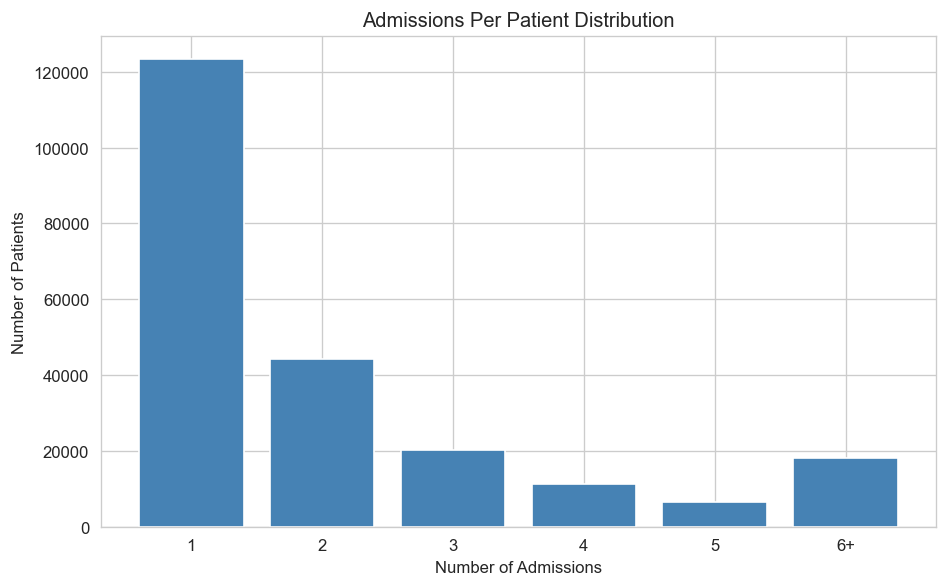

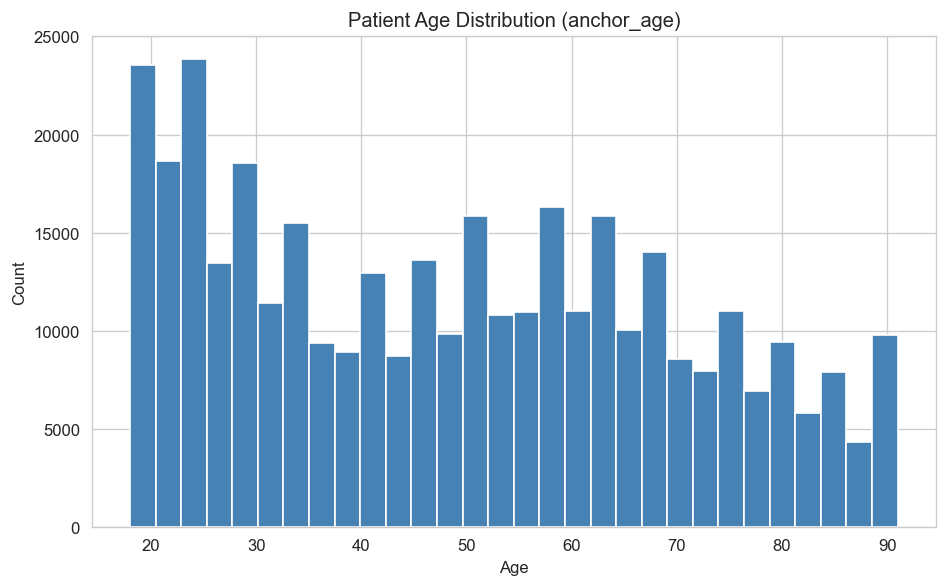

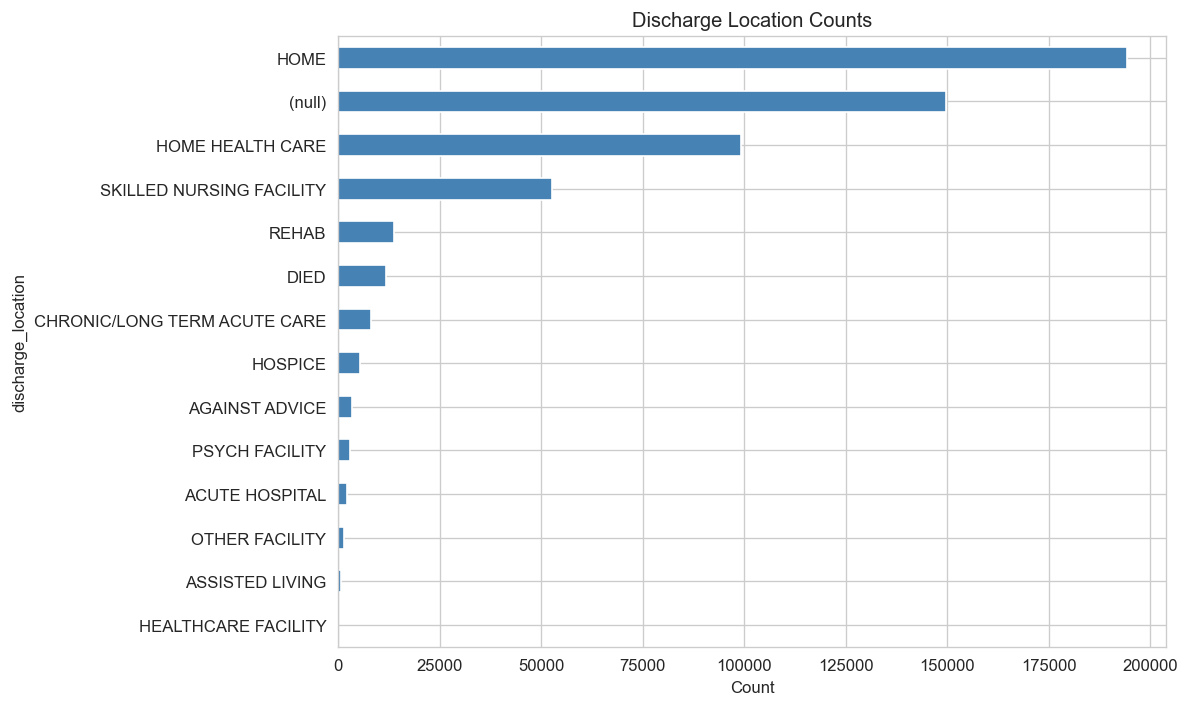

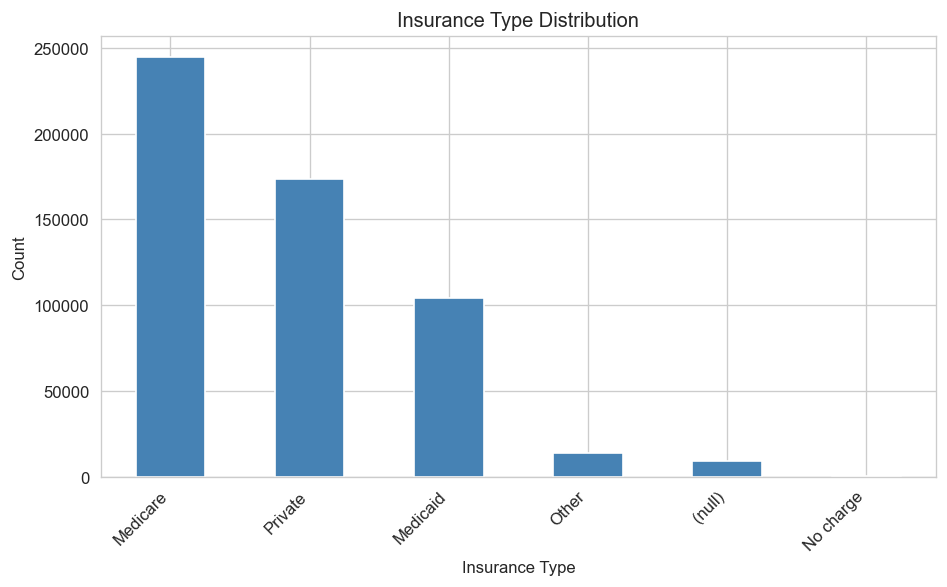

30-day readmission rough estimate (consecutive admission pairs):
  Total consecutive pairs:           322,576
  Pairs within 30 days:              99,721  (30.9%)
  Patients with 2+ admissions:       100,163
  Patients with >= 1 gap under 30d:  47,465  (47.4%)


In [6]:
# Merge for relationship exploration -- temporary, not saved
df_merged = df_admissions.merge(
    df_patients[['subject_id', 'anchor_age', 'gender']],
    on='subject_id', how='left'
)

# Admission counts per patient
adm_per_patient = df_admissions.groupby('subject_id')['hadm_id'].count()
one_admission   = int((adm_per_patient == 1).sum())
multi_admission = int((adm_per_patient > 1).sum())
print(f'Patients with exactly 1 admission: {one_admission:,}')
print(f'Patients with 2+ admissions:       {multi_admission:,}')
print()

print('Distribution of admission counts per patient (top 10):')
print(adm_per_patient.value_counts().sort_index().head(10))
print()

# -- Plot 1: Admissions Per Patient Distribution
adm_clipped = adm_per_patient.clip(upper=6)
bin_counts   = adm_clipped.value_counts().sort_index()
labels       = [str(int(i)) if int(i) < 6 else '6+' for i in bin_counts.index]

plt.figure(figsize=(8, 5))
plt.bar(labels, bin_counts.values, color='steelblue', edgecolor='white')
plt.title('Admissions Per Patient Distribution')
plt.xlabel('Number of Admissions')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

# -- Plot 2: Patient Age Distribution
plt.figure(figsize=(8, 5))
plt.hist(df_patients['anchor_age'], bins=30, color='steelblue', edgecolor='white')
plt.title('Patient Age Distribution (anchor_age)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# -- Plot 3: Discharge Location Counts (horizontal bar)
top15_discharge = (df_admissions['discharge_location']
                   .fillna('(null)')
                   .value_counts()
                   .head(15))
plt.figure(figsize=(10, 6))
top15_discharge.sort_values().plot(kind='barh', color='steelblue')
plt.title('Discharge Location Counts')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# -- Plot 4: Insurance Type Distribution
insurance_counts = (df_admissions['insurance']
                    .fillna('(null)')
                    .value_counts())
plt.figure(figsize=(8, 5))
insurance_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Insurance Type Distribution')
plt.xlabel('Insurance Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# -- 30-day readmission rough estimate via consecutive admission pairs
adm_time = df_admissions[['subject_id', 'hadm_id', 'admittime']].copy()
adm_time['admittime'] = pd.to_datetime(adm_time['admittime'])
adm_time = adm_time.sort_values(['subject_id', 'admittime'])
adm_time['next_admittime'] = adm_time.groupby('subject_id')['admittime'].shift(-1)

has_next = adm_time.dropna(subset=['next_admittime']).copy()
has_next['days_to_next'] = (has_next['next_admittime'] - has_next['admittime']).dt.days

within_30_pairs    = int((has_next['days_to_next'] <= 30).sum())
total_pairs        = len(has_next)
pct_pairs          = within_30_pairs / total_pairs * 100

patients_with_30d  = has_next[has_next['days_to_next'] <= 30]['subject_id'].nunique()
pct_patients       = patients_with_30d / multi_admission * 100 if multi_admission > 0 else 0

print('30-day readmission rough estimate (consecutive admission pairs):')
print(f'  Total consecutive pairs:           {total_pairs:,}')
print(f'  Pairs within 30 days:              {within_30_pairs:,}  ({pct_pairs:.1f}%)')
print(f'  Patients with 2+ admissions:       {multi_admission:,}')
print(f'  Patients with >= 1 gap under 30d:  {patients_with_30d:,}  ({pct_patients:.1f}%)')

Section 1 Complete. Observations feed into cohort definition in Section 2.

## Section 2: Cohort Definition

### 2A: Load and Merge Source Tables

In [7]:
df_admissions = pd.read_csv(
    ADMISSIONS_PATH,
    parse_dates=['admittime', 'dischtime', 'deathtime', 'edregtime', 'edouttime']
)
df_patients = pd.read_csv(PATIENTS_PATH)

df_merged = df_admissions.merge(df_patients, on='subject_id', how='left')
print('df_merged.shape:', df_merged.shape)
print('df_merged.columns:')
print(df_merged.columns.tolist())

df_merged.shape: (546028, 21)
df_merged.columns:
['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']


### 2B: Apply Inclusion Criteria

In [8]:
funnel = []

df = df_merged.copy()
n0, p0 = len(df), df['subject_id'].nunique()
funnel.append(('Start', n0, p0))

# Filter 1: Adults only
df = df[df['anchor_age'] >= 18].copy()
n, p = len(df), df['subject_id'].nunique()
print(f'After age filter: {n:,} admissions, {p:,} unique patients')
funnel.append(('Age >= 18', n, p))

# Filter 2: Exclude in-hospital deaths
df = df[df['hospital_expire_flag'] == 0].copy()
n, p = len(df), df['subject_id'].nunique()
print(f'After death filter: {n:,} admissions, {p:,} unique patients')
funnel.append(('No in-hosp deaths', n, p))

# Filter 3: Flag planned admissions -- do NOT drop rows
df['is_planned'] = df['admission_type'].isin(
    ['ELECTIVE', 'SURGICAL SAME DAY ADMISSION']
).astype(int)
planned_count = int(df['is_planned'].sum())
print(f'Planned admissions flagged: {planned_count:,}')

# Filter 4: Keep only patients with 2+ admissions
adm_counts  = df.groupby('subject_id')['hadm_id'].count()
multi_ids   = adm_counts[adm_counts >= 2].index
df = df[df['subject_id'].isin(multi_ids)].copy()
n, p = len(df), df['subject_id'].nunique()
print(f'After 2+ admissions filter: {n:,} admissions, {p:,} unique patients')
funnel.append(('2+ admissions', n, p))

# Filter 5: Must have at least one ICD diagnosis code
print('Loading diagnoses_icd.csv (hadm_id column only for speed)...')
df_diag = pd.read_csv(DIAGNOSES_PATH, usecols=['hadm_id'], low_memory=False)
hadm_with_icd = set(df_diag['hadm_id'].unique())
del df_diag
df = df[df['hadm_id'].isin(hadm_with_icd)].copy()
n, p = len(df), df['subject_id'].nunique()
print(f'After ICD codes filter: {n:,} admissions, {p:,} unique patients')
funnel.append(('Has ICD codes', n, p))

df_filtered = df

# Funnel summary table
print()
print(f'{"Step":<22} {"Admissions":>12} {"Patients":>10}')
print(f'{"-" * 22} {"-" * 12} {"-" * 10}')
for step, adm, pat in funnel:
    print(f'{step:<22} {adm:>12,} {pat:>10,}')

After age filter: 546,028 admissions, 223,452 unique patients
After death filter: 534,227 admissions, 218,196 unique patients
Planned admissions flagged: 55,786
After 2+ admissions filter: 414,353 admissions, 98,322 unique patients
Loading diagnoses_icd.csv (hadm_id column only for speed)...
After ICD codes filter: 413,981 admissions, 98,312 unique patients

Step                     Admissions   Patients
---------------------- ------------ ----------
Start                       546,028    223,452
Age >= 18                   546,028    223,452
No in-hosp deaths           534,227    218,196
2+ admissions               414,353     98,322
Has ICD codes               413,981     98,312


### 2C: Stratified Sample of 20,000 Patients

Available patients after filters: 98,312
Sampled 20,000 patients stratified by age_group + gender

df_cohort.shape: (83740, 23)
Unique patients: 20000

age_group distribution (unique patients):
age_group
18-30    2480
31-45    3217
46-60    4887
61-75    5555
76+      3861
Name: subject_id, dtype: int64

gender distribution:
gender
F    43477
M    40263
Name: count, dtype: int64


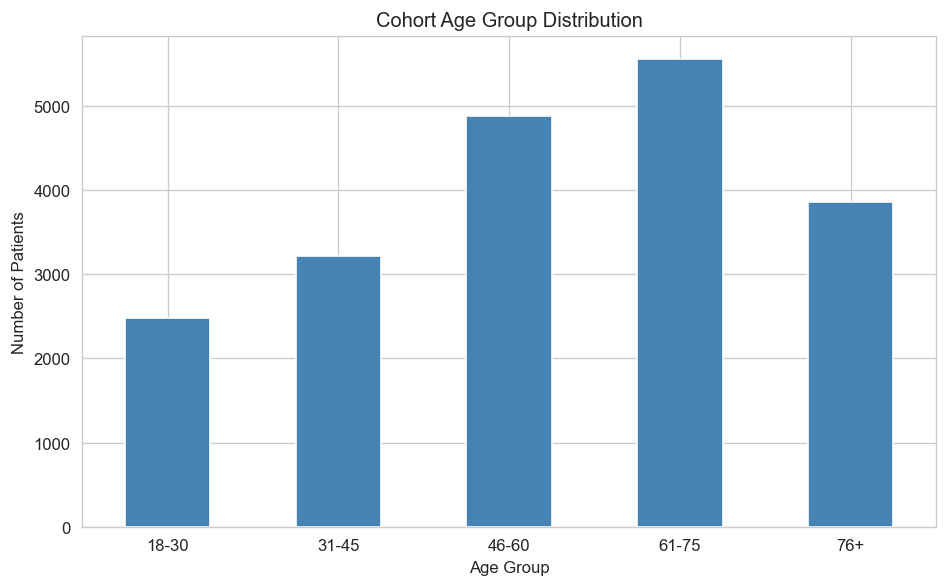

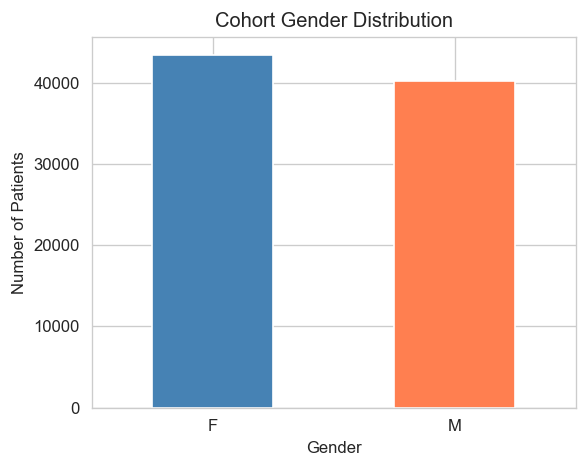

In [9]:
from sklearn.model_selection import train_test_split

# One row per patient for stratification
patient_level = (
    df_filtered.groupby('subject_id')
    .agg(anchor_age=('anchor_age', 'first'), gender=('gender', 'first'))
    .reset_index()
)

bins       = [17, 30, 45, 60, 75, 200]
age_labels = ['18-30', '31-45', '46-60', '61-75', '76+']
patient_level['age_group'] = pd.cut(
    patient_level['anchor_age'], bins=bins, labels=age_labels
)
patient_level['stratum'] = (
    patient_level['age_group'].astype(str) + '_' + patient_level['gender']
)

SAMPLE_SIZE  = 20000
n_available  = len(patient_level)
print(f'Available patients after filters: {n_available:,}')

if n_available <= SAMPLE_SIZE:
    sampled_ids = patient_level['subject_id'].tolist()
    print('All patients selected (fewer than 20,000 available)')
else:
    _, sampled = train_test_split(
        patient_level,
        test_size=SAMPLE_SIZE,
        random_state=SEED,
        stratify=patient_level['stratum']
    )
    sampled_ids = sampled['subject_id'].tolist()
    print(f'Sampled {len(sampled_ids):,} patients stratified by age_group + gender')

df_cohort = df_filtered[df_filtered['subject_id'].isin(sampled_ids)].copy()
df_cohort = df_cohort.merge(
    patient_level[['subject_id', 'age_group']], on='subject_id', how='left'
)

print()
print('df_cohort.shape:', df_cohort.shape)
print('Unique patients:', df_cohort['subject_id'].nunique())
print()
print('age_group distribution (unique patients):')
print(df_cohort.groupby('age_group', observed=True)['subject_id'].nunique().sort_index())
print()
print('gender distribution:')
print(df_cohort['gender'].value_counts())

# -- Plot 1: Age group bar chart
age_dist = df_cohort.groupby('age_group', observed=True)['subject_id'].nunique().sort_index()
plt.figure(figsize=(8, 5))
age_dist.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Cohort Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# -- Plot 2: Gender bar chart
gender_dist = df_cohort['gender'].value_counts()
plt.figure(figsize=(5, 4))
gender_dist.plot(kind='bar', color=['steelblue', 'coral'], edgecolor='white')
plt.title('Cohort Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Section 3: Readmission Label

### 3A: Compute Readmission Label

In [10]:
df_cohort = df_cohort.sort_values(['subject_id', 'admittime']).reset_index(drop=True)

# Next admission info per patient (shift -1 within group)
df_cohort['next_admittime']  = df_cohort.groupby('subject_id')['admittime'].shift(-1)
df_cohort['next_is_planned'] = df_cohort.groupby('subject_id')['is_planned'].shift(-1)

# Days from this discharge to next admission
df_cohort['days_to_next'] = (
    df_cohort['next_admittime'] - df_cohort['dischtime']
).dt.days

# True when no next admission exists for this patient
df_cohort['is_last_admission'] = df_cohort['next_admittime'].isna()

# Label logic -- first matching condition wins
conditions = [
    df_cohort['is_last_admission'],                           # NaN: no next admission
    df_cohort['days_to_next'] <= 0,                          # NaN: data error
    df_cohort['next_is_planned'].fillna(0) == 1,             # 0: planned return, not readmission
    df_cohort['days_to_next'] <= 30,                         # 1: unplanned readmission
]
choices = [np.nan, np.nan, 0.0, 1.0]
df_cohort['readmitted_30d'] = np.select(conditions, choices, default=0.0)

print('readmitted_30d value_counts (including NaN):')
print(df_cohort['readmitted_30d'].value_counts(dropna=False))

readmitted_30d value_counts (including NaN):
readmitted_30d
0.0    43648
NaN    22794
1.0    17298
Name: count, dtype: int64


### 3B: Drop Unresolvable Rows

In [11]:
n_before        = len(df_cohort)
nan_label_count = int(df_cohort['readmitted_30d'].isna().sum())
neg_days_count  = int((df_cohort['days_to_next'].fillna(0) < 0).sum())
last_adm_count  = int(df_cohort['is_last_admission'].sum())

# Drop rows where readmitted_30d is NaN (last admissions + data errors)
df_labeled = df_cohort.dropna(subset=['readmitted_30d']).copy()

# Drop any remaining rows where days_to_next < 0 (data errors)
df_labeled = df_labeled[df_labeled['days_to_next'] >= 0].copy()

n_after  = len(df_labeled)
dropped  = n_before - n_after

print(f'Rows before drop:               {n_before:,}')
print(f'  Last admissions (is_last):    {last_adm_count:,}')
print(f'  NaN labels total:             {nan_label_count:,}')
print(f'  Negative days_to_next:        {neg_days_count:,}')
print(f'Rows after drop:                {n_after:,}')
print(f'Total rows dropped:             {dropped:,}')
print()
print(f'df_labeled.shape: {df_labeled.shape}')
print(f'Unique patients remaining:   {df_labeled["subject_id"].nunique():,}')
print(f'Unique admissions remaining: {df_labeled["hadm_id"].nunique():,}')

Rows before drop:               83,740
  Last admissions (is_last):    20,000
  NaN labels total:             22,794
  Negative days_to_next:        10
Rows after drop:                60,946
Total rows dropped:             22,794

df_labeled.shape: (60946, 28)
Unique patients remaining:   19,234
Unique admissions remaining: 60,946


### 3C: Validate Readmission Label

In [12]:
total       = len(df_labeled)
pos         = int((df_labeled['readmitted_30d'] == 1).sum())
neg         = int((df_labeled['readmitted_30d'] == 0).sum())
rate        = pos / total * 100
class_ratio = neg / pos if pos > 0 else float('inf')

print(f'Overall readmission rate:  {rate:.1f}%')
print(f'Positive cases (label=1):  {pos:,}')
print(f'Negative cases (label=0):  {neg:,}')
print(f'Class ratio (neg/pos):     {class_ratio:.1f}:1')
print()

# Readmission rate by year
df_labeled = df_labeled.copy()
df_labeled['year'] = df_labeled['admittime'].dt.year
year_rate = df_labeled.groupby('year')['readmitted_30d'].mean() * 100
print('Readmission rate by year:')
print(year_rate.round(1).to_string())
print()

# Prior admissions count (0-indexed cumcount within patient)
df_labeled['prior_admissions_count'] = df_labeled.groupby('subject_id').cumcount()
pac = df_labeled['prior_admissions_count']
print('prior_admissions_count distribution:')
print(f'  mean:   {pac.mean():.1f}')
print(f'  median: {pac.median():.0f}')
print(f'  max:    {pac.max()}')
print()

# Rate by prior admission bucket
bucket_conditions = [
    df_labeled['prior_admissions_count'] == 0,
    df_labeled['prior_admissions_count'] == 1,
    df_labeled['prior_admissions_count'] == 2,
]
df_labeled['prior_bucket'] = np.select(
    bucket_conditions,
    ['0 prior', '1 prior', '2 prior'],
    default='3+ prior'
)
bucket_order = ['0 prior', '1 prior', '2 prior', '3+ prior']
rate_by_prior = (
    df_labeled.groupby('prior_bucket')['readmitted_30d'].mean() * 100
).reindex(bucket_order)

print('Readmission rate by prior admission count:')
print(rate_by_prior.round(1).to_string())

Overall readmission rate:  28.4%
Positive cases (label=1):  17,298
Negative cases (label=0):  43,648
Class ratio (neg/pos):     2.5:1

Readmission rate by year:
year
2105     0.0
2110    35.0
2111    32.5
2112    32.0
2113    25.7
2114    26.2
2115    32.7
2116    28.2
2117    29.6
2118    33.1
2119    30.8
2120    31.8
2121    28.7
2122    27.0
2123    30.0
2124    30.3
2125    26.6
2126    27.8
2127    31.7
2128    30.2
2129    26.8
2130    26.6
2131    27.0
2132    27.2
2133    24.5
2134    30.1
2135    29.4
2136    27.4
2137    30.4
2138    30.9
2139    30.1
2140    31.7
2141    29.6
2142    27.4
2143    30.7
2144    26.4
2145    28.6
2146    26.5
2147    25.8
2148    29.5
2149    27.9
2150    28.8
2151    28.6
2152    28.9
2153    28.1
2154    27.6
2155    29.8
2156    29.5
2157    28.7
2158    26.4
2159    30.9
2160    32.1
2161    29.0
2162    30.0
2163    29.4
2164    29.8
2165    29.6
2166    30.2
2167    29.8
2168    26.1
2169    25.4
2170    27.1
2171    27.6
2172    26.4
21

### 3D: Validation Plots

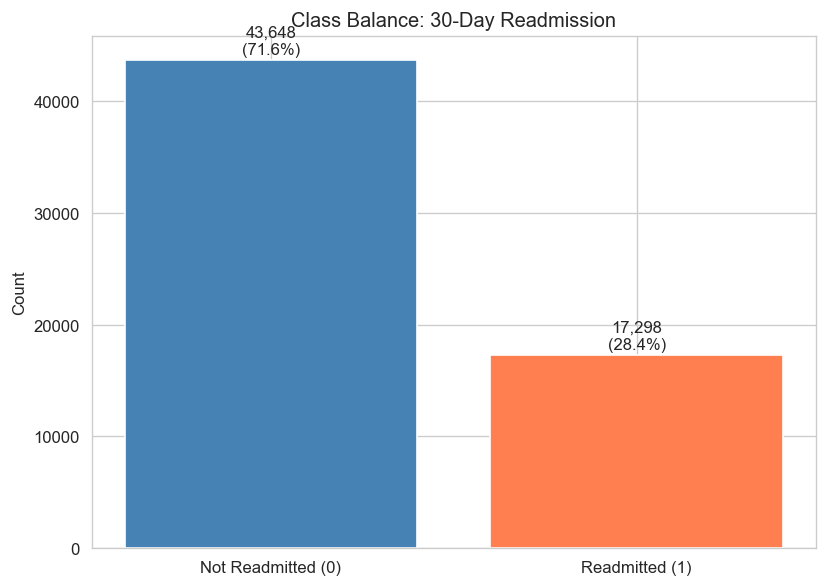

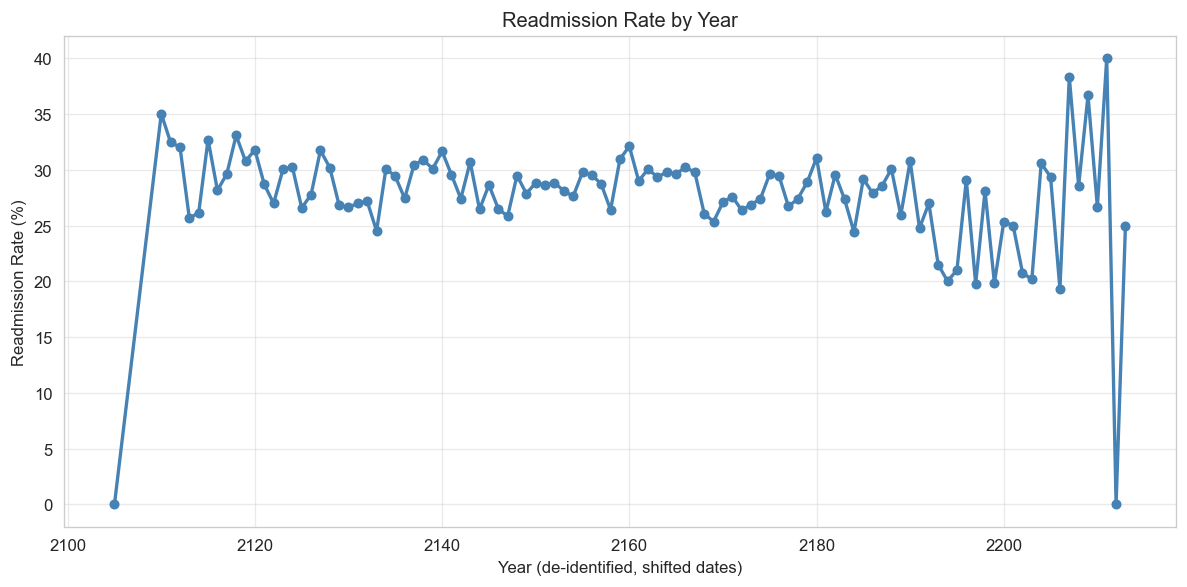

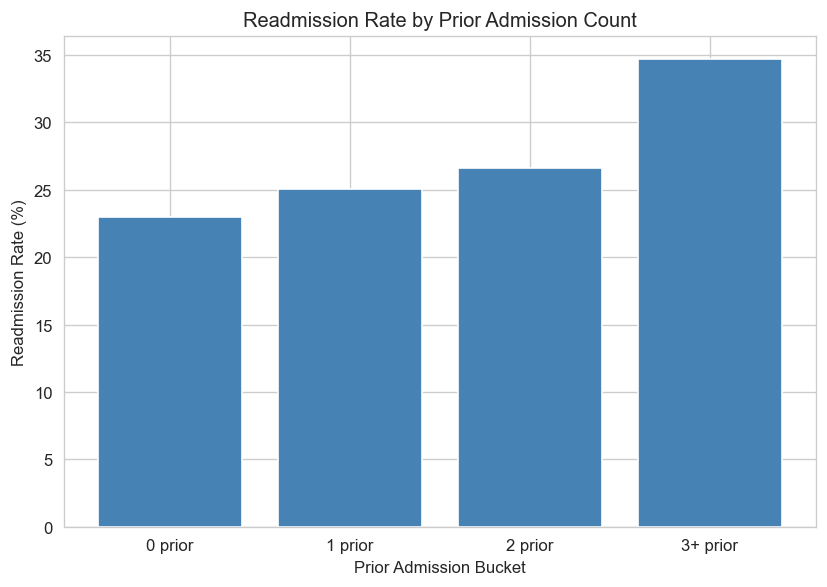

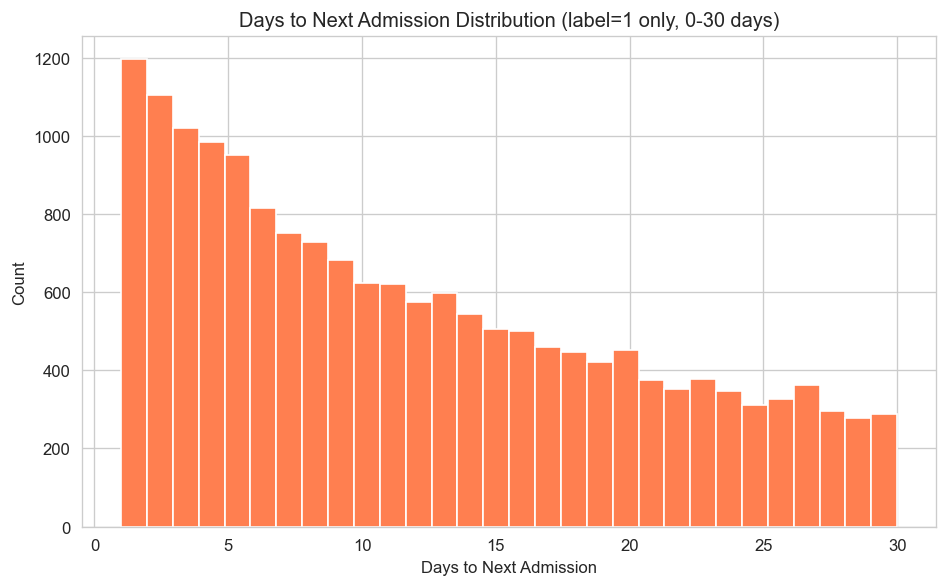

In [13]:
# -- Plot 1: Class balance bar chart
bar_labels = ['Not Readmitted (0)', 'Readmitted (1)']
bar_counts = [neg, pos]
bar_colors = ['steelblue', 'coral']

plt.figure(figsize=(7, 5))
bars = plt.bar(bar_labels, bar_counts, color=bar_colors, edgecolor='white')
for bar, count in zip(bars, bar_counts):
    pct = count / total * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.005,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )
plt.title('Class Balance: 30-Day Readmission')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# -- Plot 2: Readmission rate by year (line chart with markers)
plt.figure(figsize=(10, 5))
plt.plot(
    year_rate.index, year_rate.values,
    marker='o', color='steelblue', linewidth=2, markersize=5
)
plt.title('Readmission Rate by Year')
plt.xlabel('Year (de-identified, shifted dates)')
plt.ylabel('Readmission Rate (%)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# -- Plot 3: Readmission rate by prior admission count
plt.figure(figsize=(7, 5))
plt.bar(
    rate_by_prior.index, rate_by_prior.values,
    color='steelblue', edgecolor='white'
)
plt.title('Readmission Rate by Prior Admission Count')
plt.xlabel('Prior Admission Bucket')
plt.ylabel('Readmission Rate (%)')

rates_vals = rate_by_prior.values
is_monotone = all(
    rates_vals[i] <= rates_vals[i + 1]
    for i in range(len(rates_vals) - 1)
    if not (np.isnan(rates_vals[i]) or np.isnan(rates_vals[i + 1]))
)
if not is_monotone:
    plt.gcf().text(
        0.5, 0.01,
        'NOTE: Rate not monotonically increasing -- possible data quality concern',
        ha='center', fontsize=8, color='red'
    )
plt.tight_layout()
plt.show()

# -- Plot 4: Days to next admission for readmitted rows (label=1 only)
readmitted_rows = df_labeled[df_labeled['readmitted_30d'] == 1]
plt.figure(figsize=(8, 5))
plt.hist(readmitted_rows['days_to_next'], bins=30, color='coral', edgecolor='white')
plt.title('Days to Next Admission Distribution (label=1 only, 0-30 days)')
plt.xlabel('Days to Next Admission')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 3E: Checkpoint
- Total usable admissions: 60,946 rows x 31 columns
- Readmission rate: 28.4%
- Positive cases: 17,298
- Negative cases: 43,648
- Ready for EDA in Section 4

## Section 4: Full Exploratory Data Analysis

All plots are inline. No transformations applied yet.
This section explores raw relationships to guide preprocessing decisions.

### 4A: Target Variable Analysis

df_labeled columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'is_planned', 'age_group', 'next_admittime', 'next_is_planned', 'days_to_next', 'is_last_admission', 'readmitted_30d', 'year', 'prior_admissions_count', 'prior_bucket']
df_labeled shape: (60946, 31)

Overall readmission rate: 28.4%
Positive cases (label=1): 17,298
Negative cases (label=0): 43,648



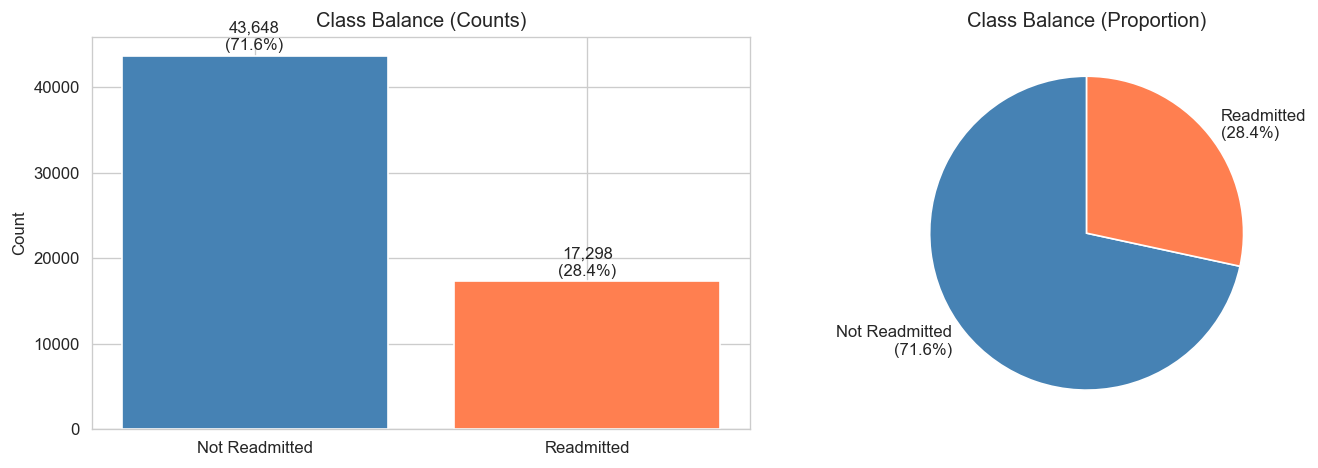

In [14]:
print('df_labeled columns:', df_labeled.columns.tolist())
print('df_labeled shape:', df_labeled.shape)
print()

total = len(df_labeled)
pos   = int((df_labeled['readmitted_30d'] == 1).sum())
neg   = int((df_labeled['readmitted_30d'] == 0).sum())
rate  = pos / total * 100

print(f'Overall readmission rate: {rate:.1f}%')
print(f'Positive cases (label=1): {pos:,}')
print(f'Negative cases (label=0): {neg:,}')
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bar_labels = ['Not Readmitted', 'Readmitted']
bar_counts = [neg, pos]
bar_colors = ['steelblue', 'coral']
bars = axes[0].bar(bar_labels, bar_counts, color=bar_colors, edgecolor='white')
for bar, count in zip(bars, bar_counts):
    pct = count / total * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.005,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )
axes[0].set_title('Class Balance (Counts)')
axes[0].set_ylabel('Count')

pie_labels = [
    f'Not Readmitted\n({neg / total * 100:.1f}%)',
    f'Readmitted\n({pos / total * 100:.1f}%)'
]
axes[1].pie(
    [neg, pos], labels=pie_labels,
    colors=bar_colors, startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
axes[1].set_title('Class Balance (Proportion)')

plt.tight_layout()
plt.show()

### 4B: Numeric Feature Distributions (Before Any Transformation)

Reading raw distributions to decide winsorization thresholds. 
Observe skewness, outliers, and differences by readmission status.

In [15]:
if 'los_days' not in df_labeled.columns:
    df_labeled['los_days'] = (
        df_labeled['dischtime'] - df_labeled['admittime']
    ).dt.days
    print('Computed los_days')
else:
    print('los_days already present')

if 'came_via_ed' not in df_labeled.columns:
    df_labeled['came_via_ed'] = df_labeled['edregtime'].notna().astype(int)
    print('Computed came_via_ed')
else:
    print('came_via_ed already present')

numeric_cols = ['anchor_age', 'los_days', 'prior_admissions_count']
print()
print('Descriptive statistics:')
print(df_labeled[numeric_cols].describe().round(2).to_string())
print()
print('Skewness:')
print(df_labeled[numeric_cols].skew().round(3).to_string())

Computed los_days
Computed came_via_ed

Descriptive statistics:
       anchor_age  los_days  prior_admissions_count
count    60946.00  60946.00                60946.00
mean        58.05      4.23                    4.03
std         17.75      6.86                    7.21
min         18.00     -1.00                    0.00
25%         46.00      1.00                    0.00
50%         59.00      2.00                    2.00
75%         71.00      5.00                    5.00
max         91.00    295.00                   97.00

Skewness:
anchor_age               -0.250
los_days                  7.561
prior_admissions_count    4.524


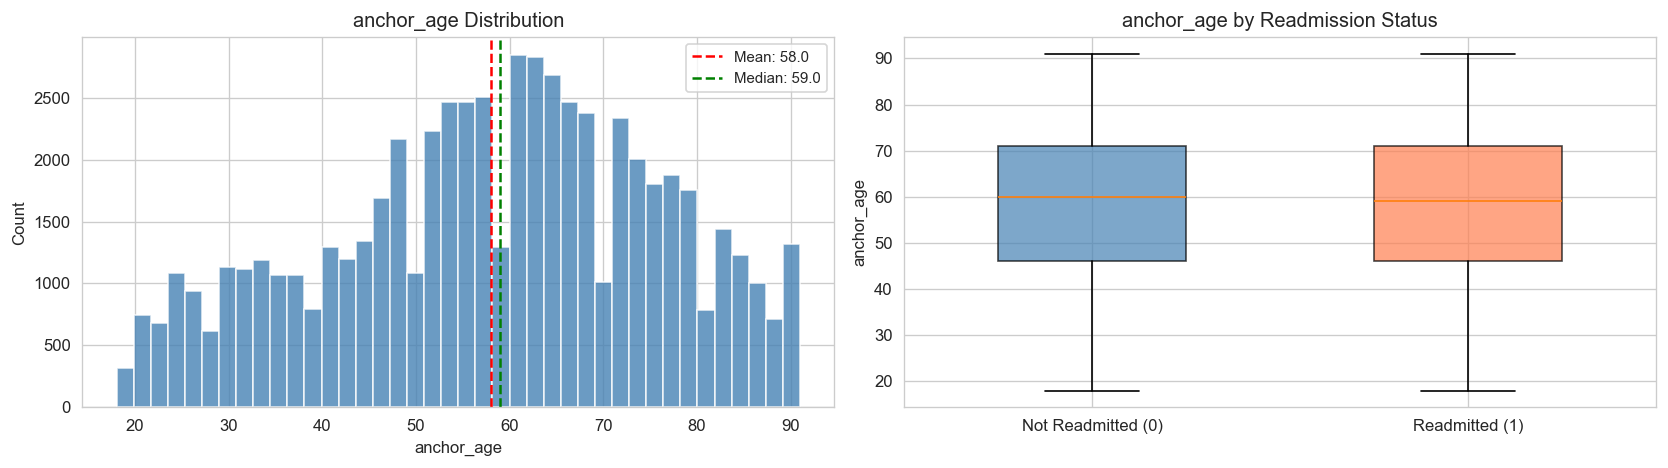

anchor_age: mean=58.0, median=59.0, skewness=-0.25, 95th pct=85.0, 99th pct=91.0, max=91.0



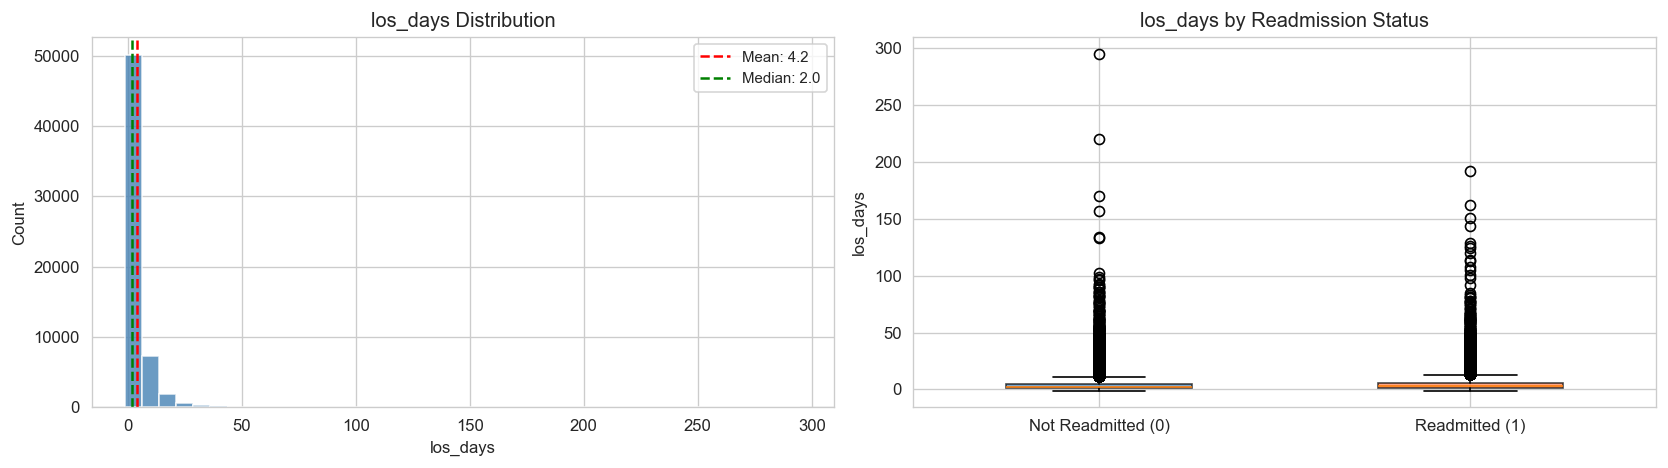

los_days: mean=4.2, median=2.0, skewness=7.56, 95th pct=14.0, 99th pct=32.0, max=295.0



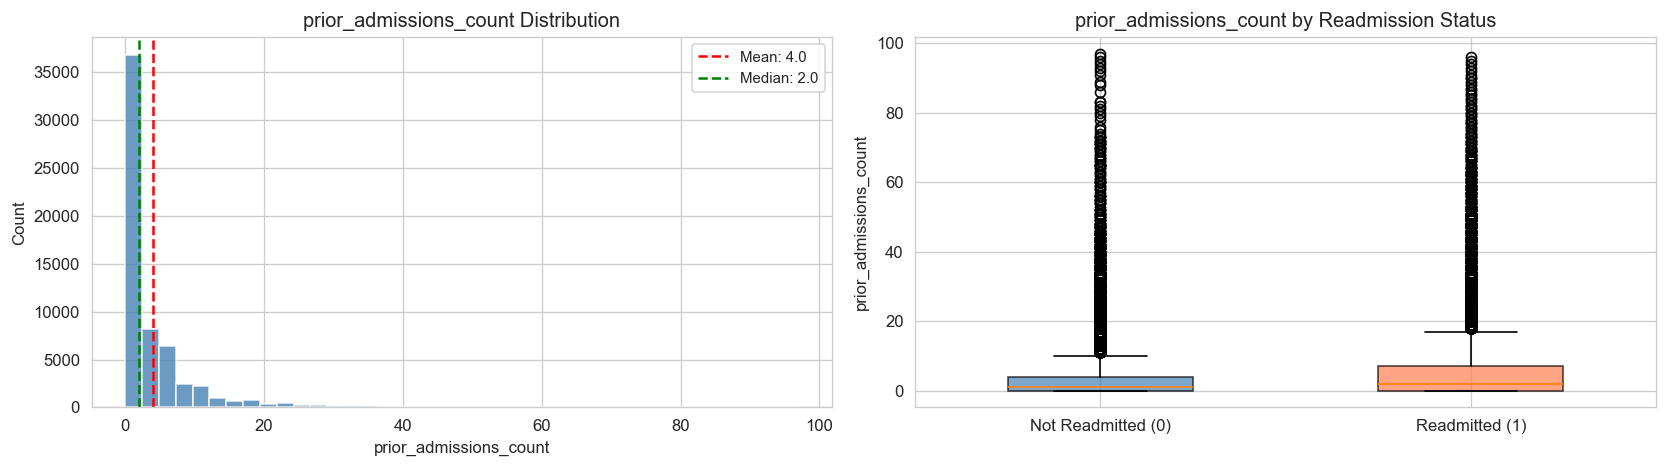

prior_admissions_count: mean=4.0, median=2.0, skewness=4.52, 95th pct=16.0, 99th pct=35.0, max=97.0



In [16]:
numeric_cols = ['anchor_age', 'los_days', 'prior_admissions_count']

for col in numeric_cols:
    col_data   = df_labeled[col].dropna()
    col_mean   = float(col_data.mean())
    col_median = float(col_data.median())
    col_skew   = float(col_data.skew())
    col_p95    = float(col_data.quantile(0.95))
    col_p99    = float(col_data.quantile(0.99))
    col_max    = float(col_data.max())

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(col_data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].axvline(col_mean,   color='red',   linestyle='--', linewidth=1.5,
                    label=f'Mean: {col_mean:.1f}')
    axes[0].axvline(col_median, color='green', linestyle='--', linewidth=1.5,
                    label=f'Median: {col_median:.1f}')
    axes[0].legend(fontsize=9)
    axes[0].set_title(f'{col} Distribution')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')

    group0 = df_labeled.loc[df_labeled['readmitted_30d'] == 0, col].dropna().values
    group1 = df_labeled.loc[df_labeled['readmitted_30d'] == 1, col].dropna().values
    bp = axes[1].boxplot([group0, group1], patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], ['steelblue', 'coral']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1].set_xticks([1, 2])
    axes[1].set_xticklabels(['Not Readmitted (0)', 'Readmitted (1)'])
    axes[1].set_title(f'{col} by Readmission Status')
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

    print(
        f'{col}: mean={col_mean:.1f}, median={col_median:.1f}, '
        f'skewness={col_skew:.2f}, 95th pct={col_p95:.1f}, '
        f'99th pct={col_p99:.1f}, max={col_max:.1f}'
    )
    print()

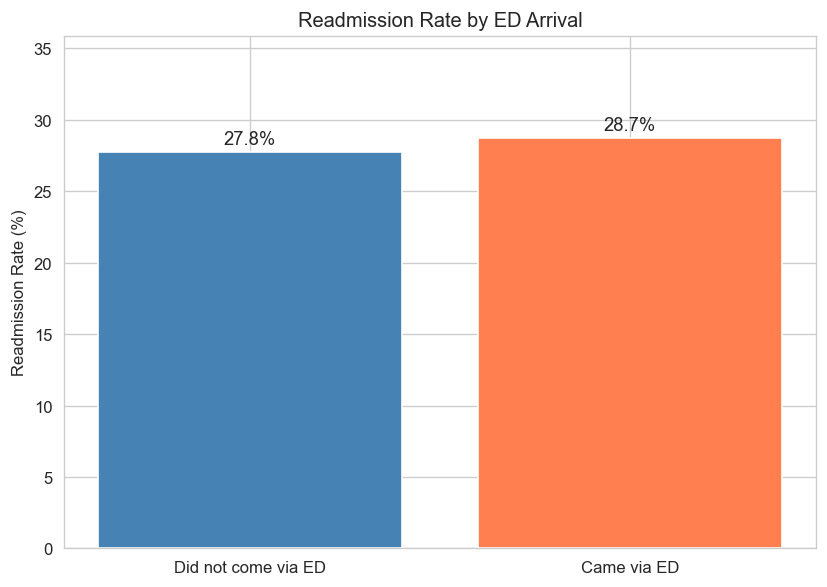

In [17]:
ed_rate   = df_labeled.groupby('came_via_ed')['readmitted_30d'].mean() * 100
ed_labels = ['Did not come via ED', 'Came via ED']
ed_vals   = [float(ed_rate.get(0, 0.0)), float(ed_rate.get(1, 0.0))]

plt.figure(figsize=(7, 5))
bars = plt.bar(ed_labels, ed_vals, color=['steelblue', 'coral'], edgecolor='white')
for bar, val in zip(bars, ed_vals):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=11
    )
plt.title('Readmission Rate by ED Arrival')
plt.ylabel('Readmission Rate (%)')
plt.ylim(0, max(ed_vals) * 1.25)
plt.tight_layout()
plt.show()

### 4C: Categorical Features vs Readmission Rate

Each bar shows the readmission rate for that category.
Sorted highest to lowest. This is the fairness audit foundation.

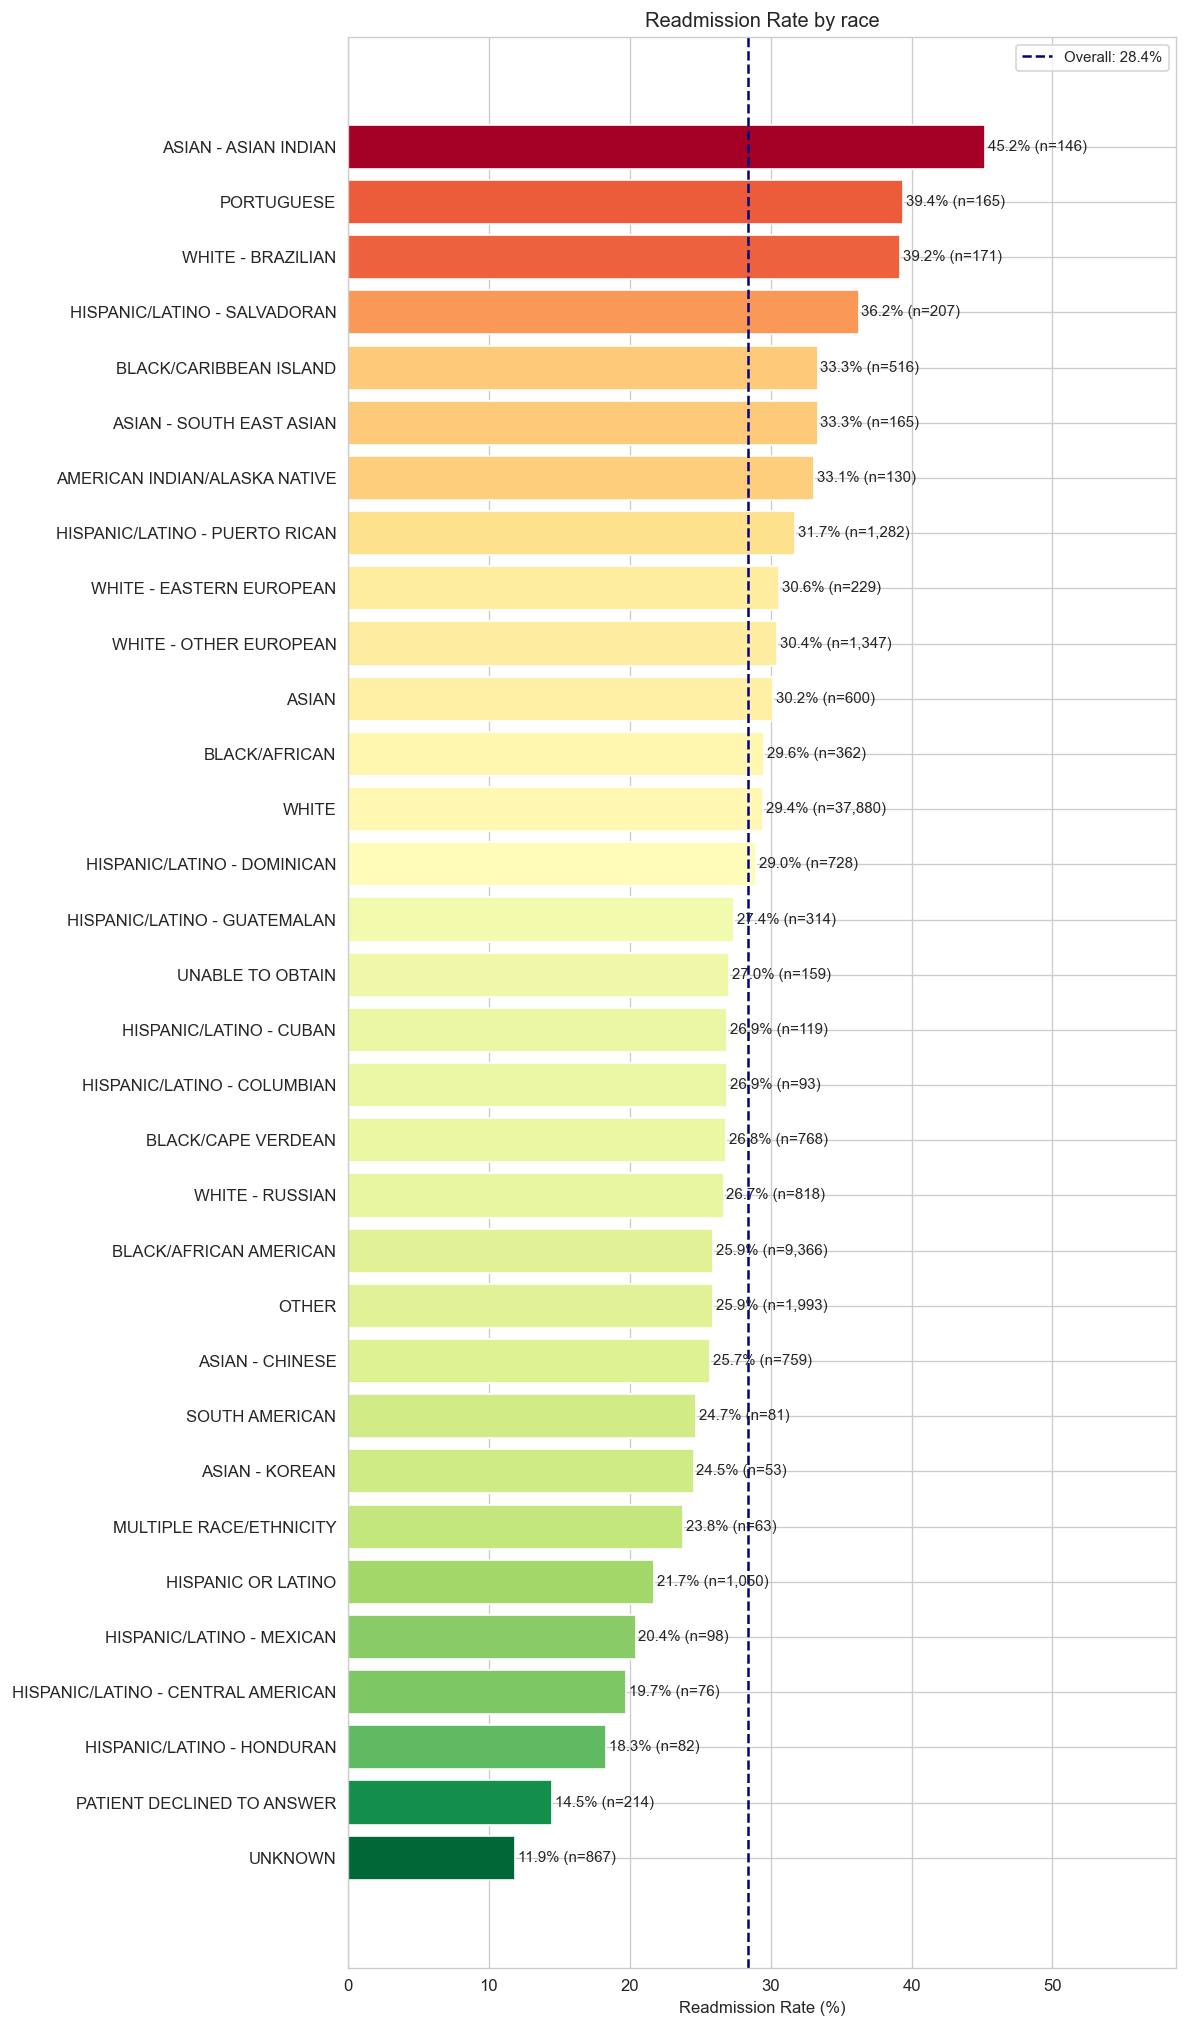

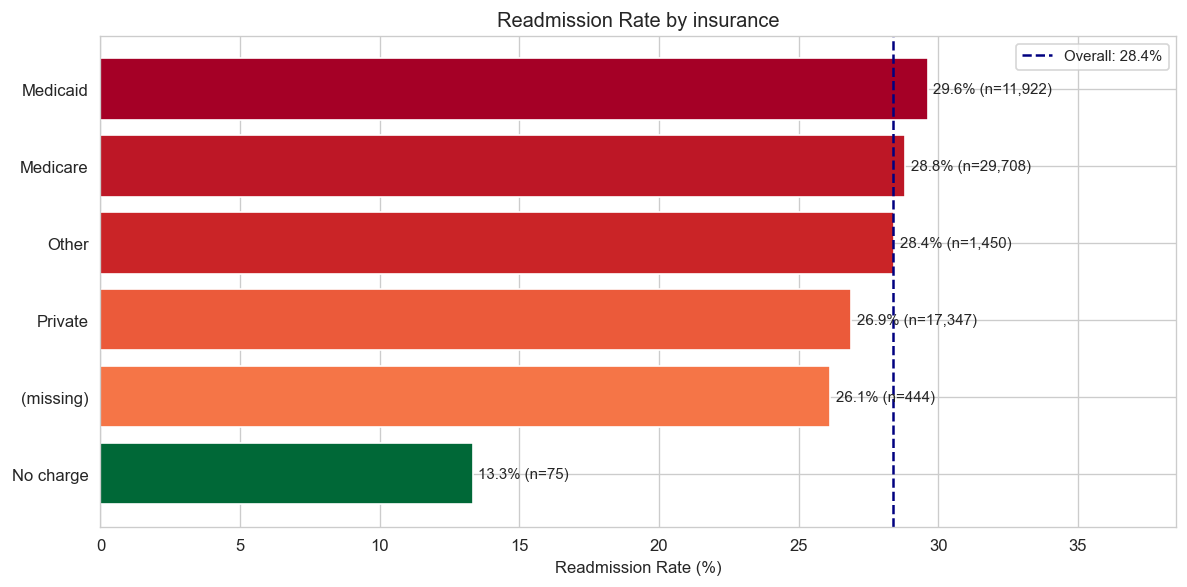

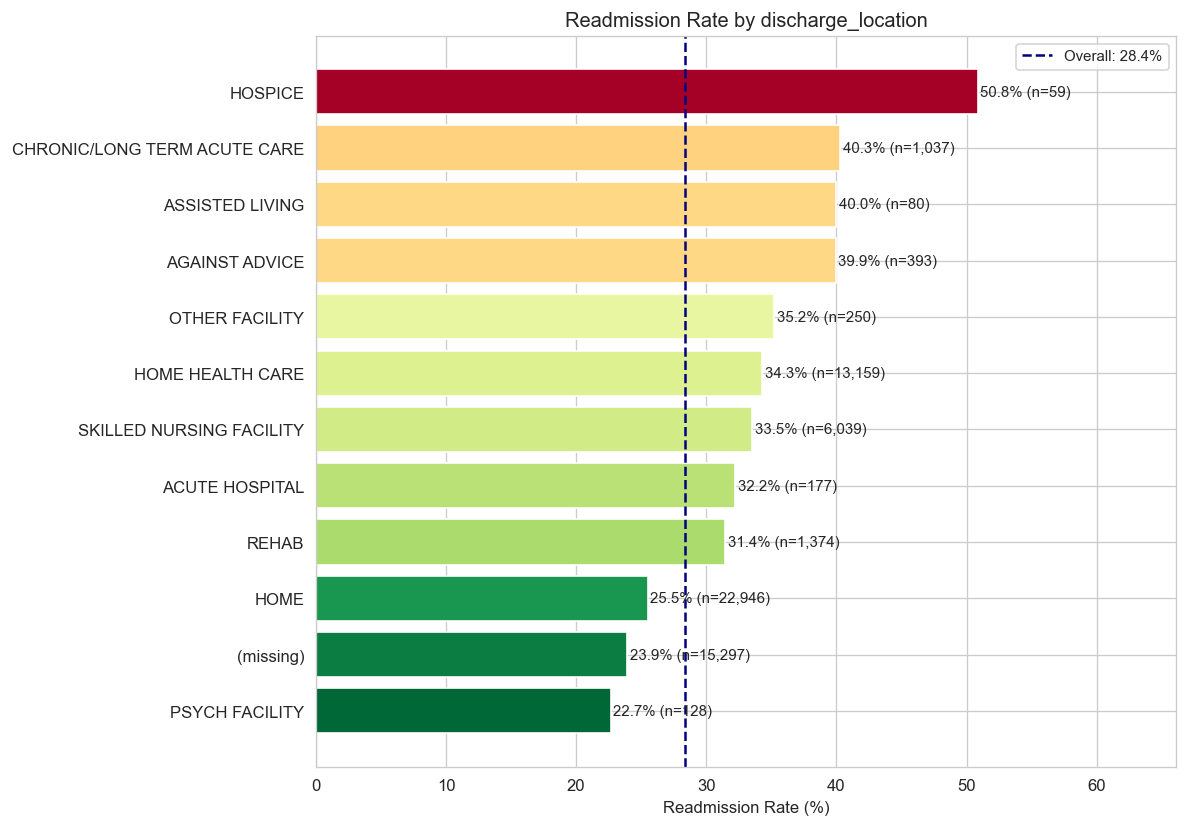

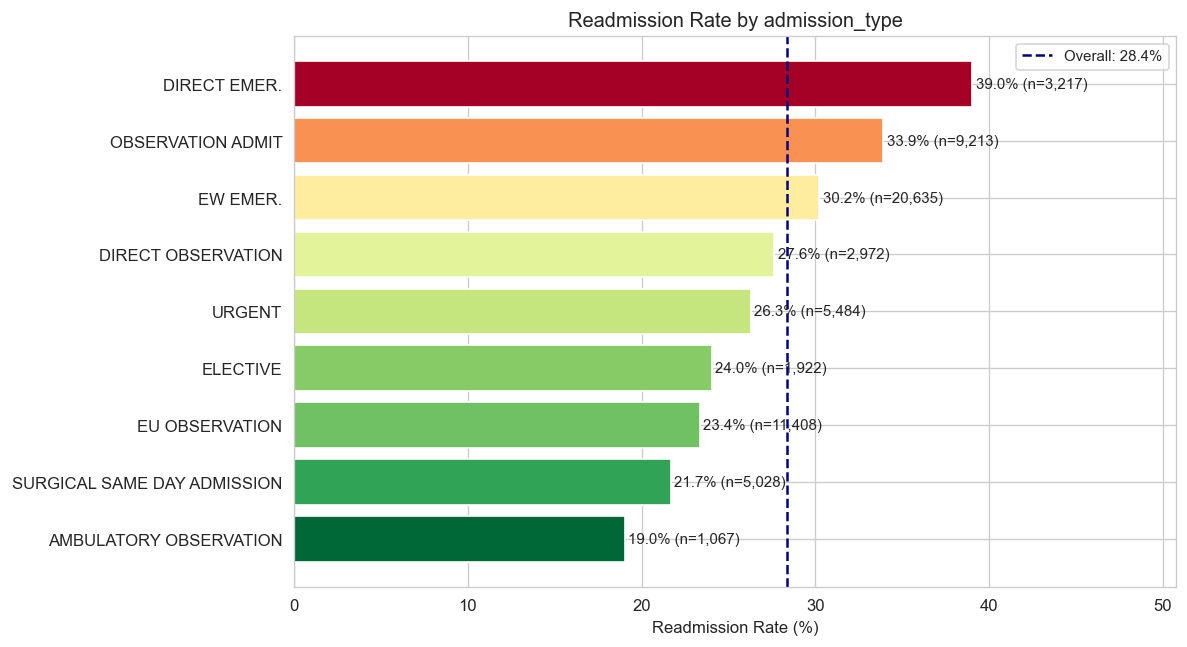

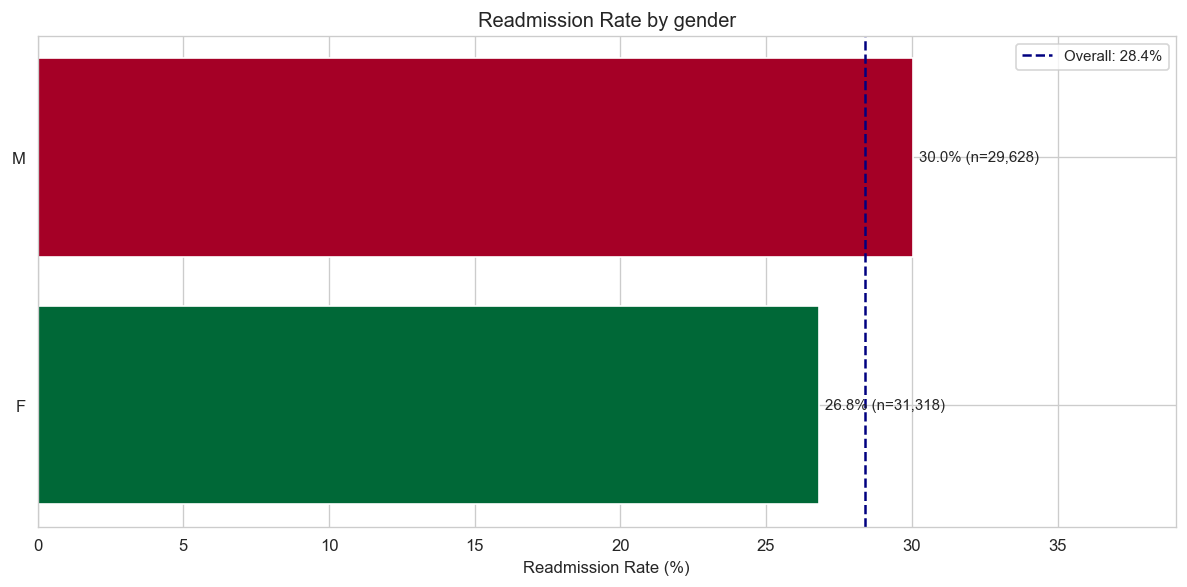

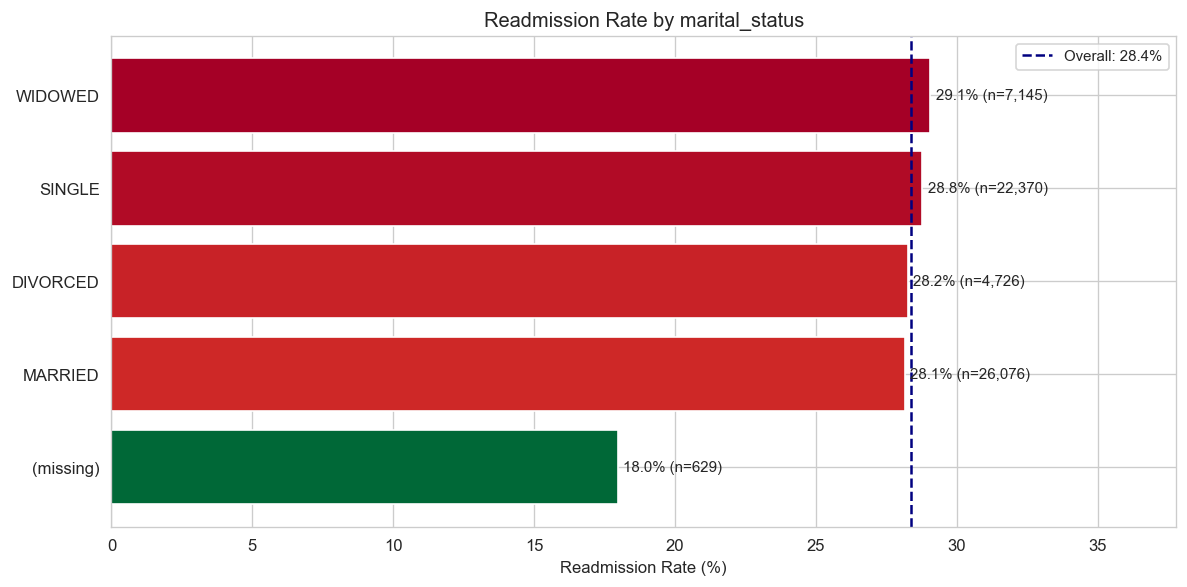


Summary: Highest vs Lowest Readmission Rate by Feature
Feature                High Category                    Rate  Low Category                     Rate     Gap
-----------------------------------------------------------------------------------------------------------
race                   ASIAN - ASIAN INDIAN            45.2%  UNKNOWN                         11.9%   33.3%
insurance              Medicaid                        29.6%  No charge                       13.3%   16.3%
discharge_location     HOSPICE                         50.8%  PSYCH FACILITY                  22.7%   28.2%
admission_type         DIRECT EMER.                    39.0%  AMBULATORY OBSERVATION          19.0%   20.0%
gender                 M                               30.0%  F                               26.8%    3.2%
marital_status         WIDOWED                         29.1%  (missing)                       18.0%   11.1%


In [18]:
import matplotlib.colors as mcolors

cat_features = [
    'race', 'insurance', 'discharge_location',
    'admission_type', 'gender', 'marital_status'
]

overall_rate = df_labeled['readmitted_30d'].mean() * 100
summary_rows = []

for feat in cat_features:
    group  = df_labeled.groupby(feat, dropna=False)['readmitted_30d']
    rates  = (group.mean() * 100).rename('rate')
    counts = group.count().rename('count')
    stats  = pd.concat([rates, counts], axis=1).reset_index()
    stats.columns = ['category', 'rate', 'count']
    stats['category'] = stats['category'].fillna('(missing)').astype(str)
    stats = stats[stats['count'] >= 50].sort_values('rate', ascending=False)

    if stats.empty:
        print(f'{feat}: no categories with count >= 50')
        continue

    cmap   = plt.cm.RdYlGn_r
    norm   = mcolors.Normalize(
        vmin=stats['rate'].min(), vmax=stats['rate'].max()
    )
    colors = [cmap(norm(r)) for r in stats['rate']]

    fig, ax = plt.subplots(figsize=(10, max(5, len(stats) * 0.5 + 1)))
    bars    = ax.barh(stats['category'], stats['rate'], color=colors)

    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(
            bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{row["rate"]:.1f}% (n={row["count"]:,})',
            va='center', fontsize=9
        )

    ax.axvline(overall_rate, color='navy', linestyle='--', linewidth=1.5,
               label=f'Overall: {overall_rate:.1f}%')
    ax.legend(fontsize=9)
    ax.set_title(f'Readmission Rate by {feat}')
    ax.set_xlabel('Readmission Rate (%)')
    ax.set_xlim(0, stats['rate'].max() * 1.3)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    highest = stats.iloc[0]
    lowest  = stats.iloc[-1]
    summary_rows.append({
        'feature':      feat,
        'highest_cat':  str(highest['category']),
        'highest_rate': round(float(highest['rate']), 1),
        'lowest_cat':   str(lowest['category']),
        'lowest_rate':  round(float(lowest['rate']), 1),
        'gap_pct':      round(float(highest['rate'] - lowest['rate']), 1)
    })

print()
print('Summary: Highest vs Lowest Readmission Rate by Feature')
hdr = f'{"Feature":<22} {"High Category":<30} {"Rate":>6}  {"Low Category":<30} {"Rate":>6}  {"Gap":>6}'
print(hdr)
print('-' * len(hdr))
for row in summary_rows:
    print(
        f'{row["feature"]:<22} {row["highest_cat"]:<30} '
        f'{row["highest_rate"]:>5.1f}%  {row["lowest_cat"]:<30} '
        f'{row["lowest_rate"]:>5.1f}%  {row["gap_pct"]:>5.1f}%'
    )

### 4D: Correlation Analysis

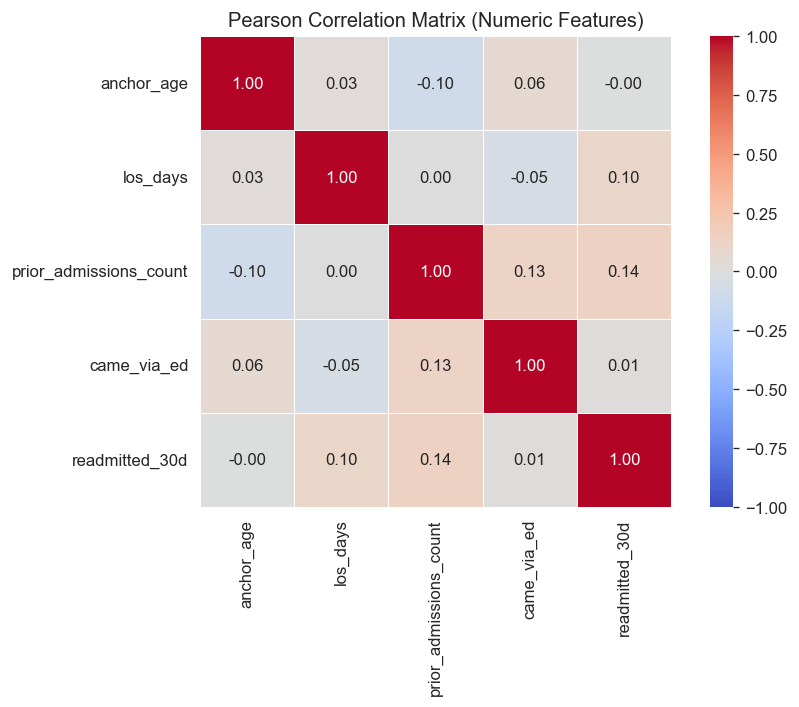

In [19]:
corr_cols = [
    'anchor_age', 'los_days', 'prior_admissions_count',
    'came_via_ed', 'readmitted_30d'
]

if 'los_days' not in df_labeled.columns:
    df_labeled['los_days'] = (
        df_labeled['dischtime'] - df_labeled['admittime']
    ).dt.days
if 'came_via_ed' not in df_labeled.columns:
    df_labeled['came_via_ed'] = df_labeled['edregtime'].notna().astype(int)

corr_matrix = df_labeled[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
plt.title('Pearson Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()

Point-Biserial Correlation with Readmission Label:
Feature                       Correlation        p-value  Significant
----------------------------------------------------------------------
prior_admissions_count             0.1387    2.9226e-259        Yes *
los_days                           0.1045    1.1969e-147        Yes *
came_via_ed                        0.0098     1.5300e-02        Yes *
anchor_age                        -0.0043     2.8485e-01           No



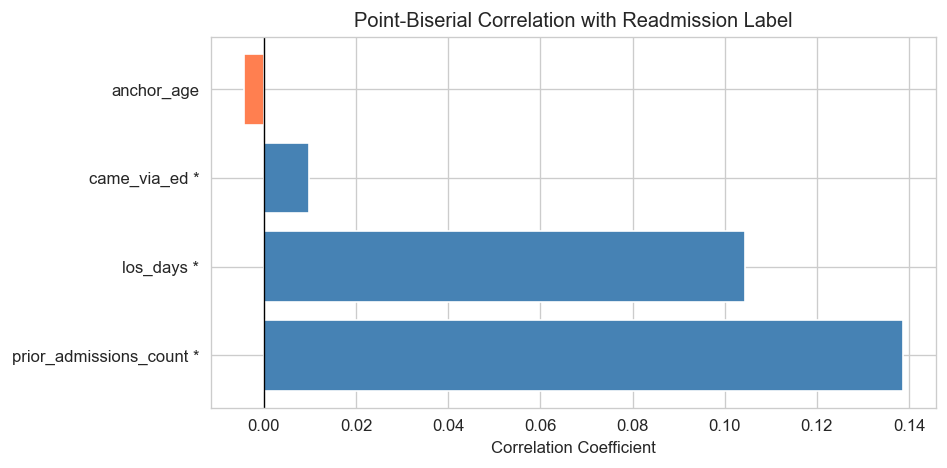

In [20]:
from scipy.stats import pointbiserialr

numeric_features = ['anchor_age', 'los_days', 'prior_admissions_count', 'came_via_ed']
target           = df_labeled['readmitted_30d']

pb_results = []
for feat in numeric_features:
    feat_vals  = df_labeled[feat].dropna()
    tgt_vals   = target.loc[feat_vals.index]
    corr, pval = pointbiserialr(feat_vals, tgt_vals)
    pb_results.append({
        'feature':     feat,
        'correlation': round(float(corr), 4),
        'p_value':     float(pval),
        'significant': bool(pval < 0.05)
    })

pb_df = pd.DataFrame(pb_results)
pb_df['abs_corr'] = pb_df['correlation'].abs()
pb_df = pb_df.sort_values('abs_corr', ascending=False).drop(columns='abs_corr')

print('Point-Biserial Correlation with Readmission Label:')
print(f'{"Feature":<28} {"Correlation":>12} {"p-value":>14} {"Significant":>12}')
print('-' * 70)
for _, row in pb_df.iterrows():
    sig = 'Yes *' if row['significant'] else 'No'
    print(f'{row["feature"]:<28} {row["correlation"]:>12.4f} {row["p_value"]:>14.4e} {sig:>12}')
print()

bar_colors_pb = ['steelblue' if c >= 0 else 'coral' for c in pb_df['correlation']]
labels_pb = [
    f'{r["feature"]} *' if r['significant'] else r['feature']
    for _, r in pb_df.iterrows()
]

plt.figure(figsize=(8, 4))
plt.barh(labels_pb, pb_df['correlation'], color=bar_colors_pb, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Point-Biserial Correlation with Readmission Label')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

### 4E: Missing Value Analysis

Columns with missing values:
Column                            Missing Count  Missing %
------------------------------------------------------------
deathtime                                60,946    100.00%
dod                                      41,211     67.62%
edregtime                                20,465     33.58%
edouttime                                20,465     33.58%
discharge_location                       15,297     25.10%
marital_status                              629      1.03%
insurance                                   444      0.73%
language                                     30      0.05%



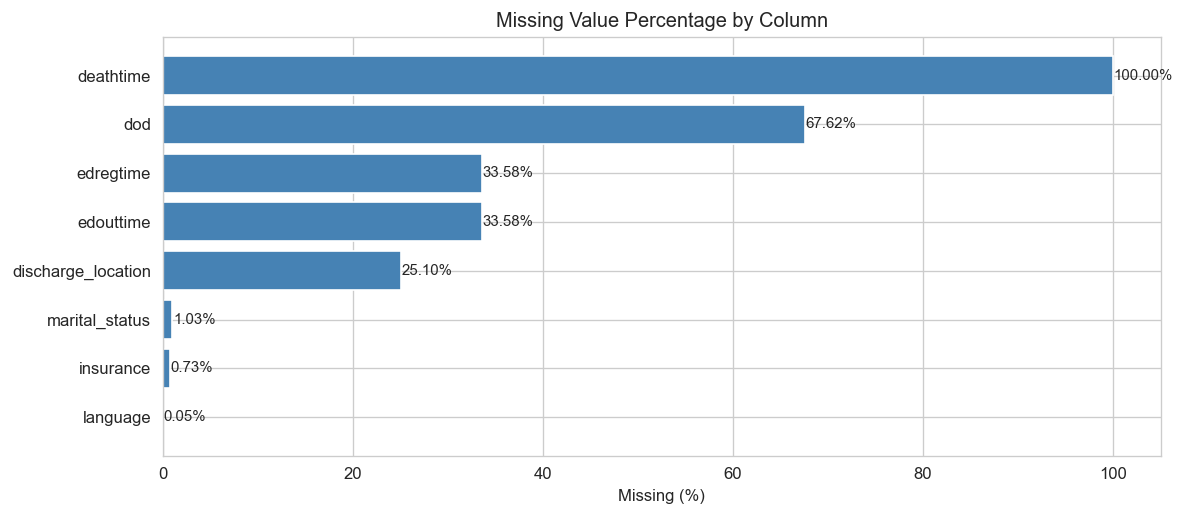

Missingness correlation with readmission (discharge_location):
  Missing:     23.9% readmission rate
  Not missing: 29.9% readmission rate
  Chi-square:  198.06  (df=1)
  p-value:     0.0000
  Conclusion: Significant -- missingness IS correlated with readmission



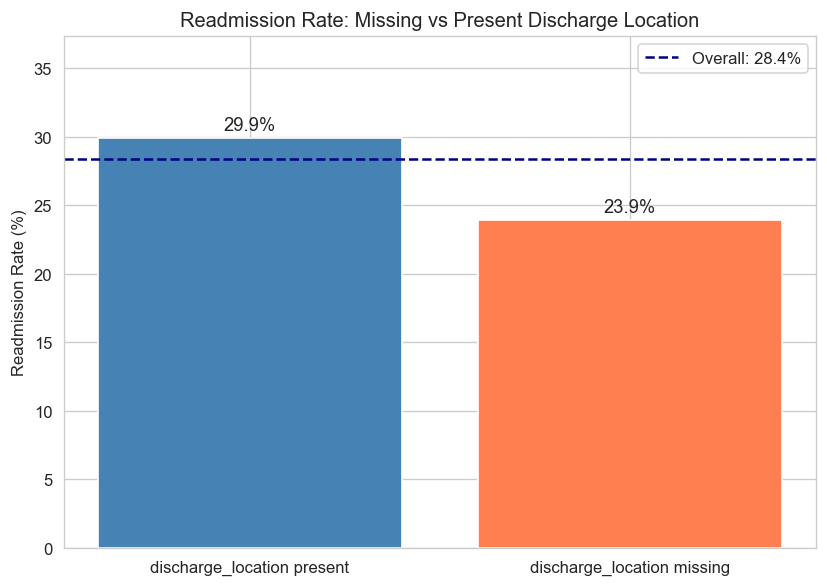

In [21]:
from scipy.stats import chi2_contingency

overall_rate_e = df_labeled['readmitted_30d'].mean() * 100
total_rows     = len(df_labeled)
missing        = df_labeled.isnull().sum()
missing        = missing[missing > 0].sort_values(ascending=False)
missing_pct    = (missing / total_rows * 100).round(2)

print('Columns with missing values:')
print(f'{"Column":<32} {"Missing Count":>14} {"Missing %":>10}')
print('-' * 60)
for col in missing.index:
    print(f'{col:<32} {missing[col]:>14,} {missing_pct[col]:>9.2f}%')
print()

if len(missing) > 0:
    plt.figure(figsize=(10, max(4, len(missing) * 0.55)))
    plt.barh(
        missing.index[::-1],
        missing_pct.values[::-1],
        color='steelblue', edgecolor='white'
    )
    for i, (col, pct) in enumerate(
        zip(missing.index[::-1], missing_pct.values[::-1])
    ):
        plt.text(pct + 0.05, i, f'{pct:.2f}%', va='center', fontsize=9)
    plt.title('Missing Value Percentage by Column')
    plt.xlabel('Missing (%)')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found in df_labeled.')

df_labeled['discharge_location_missing'] = (
    df_labeled['discharge_location'].isna().astype(int)
)

rate_missing = float(
    df_labeled.loc[
        df_labeled['discharge_location_missing'] == 1, 'readmitted_30d'
    ].mean() * 100
)
rate_present = float(
    df_labeled.loc[
        df_labeled['discharge_location_missing'] == 0, 'readmitted_30d'
    ].mean() * 100
)

ct = pd.crosstab(
    df_labeled['discharge_location_missing'],
    df_labeled['readmitted_30d']
)
chi2, p, dof, _ = chi2_contingency(ct)
is_sig = bool(p < 0.05)

print('Missingness correlation with readmission (discharge_location):')
print(f'  Missing:     {rate_missing:.1f}% readmission rate')
print(f'  Not missing: {rate_present:.1f}% readmission rate')
print(f'  Chi-square:  {chi2:.2f}  (df={dof})')
print(f'  p-value:     {p:.4f}')
print(
    f'  Conclusion: {"Significant" if is_sig else "Not significant"} -- '
    f'missingness {"IS" if is_sig else "is NOT"} correlated with readmission'
)
print()

bar_labels2 = ['discharge_location present', 'discharge_location missing']
bar_vals2   = [rate_present, rate_missing]

plt.figure(figsize=(7, 5))
bars2 = plt.bar(bar_labels2, bar_vals2, color=['steelblue', 'coral'], edgecolor='white')
for bar, val in zip(bars2, bar_vals2):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=11
    )
plt.axhline(overall_rate_e, color='navy', linestyle='--',
            label=f'Overall: {overall_rate_e:.1f}%')
plt.legend()
plt.title('Readmission Rate: Missing vs Present Discharge Location')
plt.ylabel('Readmission Rate (%)')
plt.ylim(0, max(bar_vals2) * 1.25)
plt.tight_layout()
plt.show()

### 4E Complete

Missing value analysis confirms (fill in from cell output above after running):
- discharge_location: X% missing
- marital_status: X% missing
- insurance: X% missing

Strategy for Section 6 (preprocessing):
- Create `discharge_location_missing` and `marital_status_missing` indicator flags
  (chi-square test above confirms whether missingness is informative)
- Fill remaining NaN with `(missing)` category label before one-hot encoding

Section 4F (ICD/CCSR vs Readmission) will run after Section 5 builds the CCSR features.

## Section 5: CCSR Feature Engineering

### 5A: Load and Filter Cohort Diagnoses

In [50]:
# Load full diagnoses file -- 6.36M rows, low_memory=False required
df_diag_all = pd.read_csv(
    str(DIAGNOSES_PATH),
    low_memory=False,
    dtype={'icd_code': str, 'icd_version': int}
)
print('Original diagnoses shape:', df_diag_all.shape)

# Filter to only hadm_ids that are in our labeled cohort
cohort_hadm_ids = set(df_labeled['hadm_id'].tolist())
df_diag = df_diag_all[df_diag_all['hadm_id'].isin(cohort_hadm_ids)].copy()
del df_diag_all

n_orig     = df_diag_all.shape[0] if False else 6364488
n_filtered = len(df_diag)
pct        = n_filtered / 6364488 * 100
print(f'Filtered diagnoses shape: {df_diag.shape}')
print(f'% retained: {pct:.1f}%')
print()

# Split by ICD version
df_diag_10 = df_diag[df_diag['icd_version'] == 10].copy()
df_diag_9  = df_diag[df_diag['icd_version'] == 9].copy()

print(f'ICD-10 row count: {len(df_diag_10):,}')
print(f'ICD-9  row count: {len(df_diag_9):,}')

hadm_10  = set(df_diag_10['hadm_id'])
hadm_9   = set(df_diag_9['hadm_id'])
n_both   = len(hadm_10 & hadm_9)
print(f'Admissions with both ICD-9 and ICD-10: {n_both:,}')

Original diagnoses shape: (6364488, 5)
Filtered diagnoses shape: (735982, 5)
% retained: 11.6%

ICD-10 row count: 355,140
ICD-9  row count: 380,842
Admissions with both ICD-9 and ICD-10: 3


### 5B: ICD-10 CCSR Mapping

In [51]:
ccsr_map_path = str(CCSR_DIR / 'icd10_ccsr' / 'DXCCSR_v2025-1.csv')
df_ccsr_map = pd.read_csv(ccsr_map_path, low_memory=False)

print(f'CCSR mapping file shape: {df_ccsr_map.shape}')
print('Raw columns (first 10):')
for c in df_ccsr_map.columns[:10]:
    print(f'  {c!r}')
print()
print('First 2 rows (ICD code + first CCSR category columns):')
print(df_ccsr_map.iloc[:2, [0, 6, 8, 10, 12, 14, 16]].to_string())
print()

# Fix column names: replace quotes FIRST, then strip (quotes are outermost)
df_ccsr_map.columns = (
    df_ccsr_map.columns.str.replace("'", '', regex=False).str.strip()
)
print('Fixed column names:')
for c in df_ccsr_map.columns:
    print(f'  {c!r}')
print()

# Identify columns dynamically (never hardcode column names)
icd10_col     = 'ICD-10-CM CODE'
ccsr_cat_cols = [
    c for c in df_ccsr_map.columns
    if c.startswith('CCSR CATEGORY') and 'DESCRIPTION' not in c
]
print(f'ICD-10 code column: {icd10_col!r}')
print(f'CCSR category columns: {ccsr_cat_cols}')
print()

# Fix values in ICD code column
df_ccsr_map[icd10_col] = (
    df_ccsr_map[icd10_col].str.replace("'", '', regex=False).str.strip()
)

# Fix values in CCSR category columns
for col in ccsr_cat_cols:
    df_ccsr_map[col] = (
        df_ccsr_map[col].str.replace("'", '', regex=False).str.strip()
    )

# Melt to long format: one row per (icd_code, ccsr_code) pair
df_map10_long = (
    df_ccsr_map[[icd10_col] + ccsr_cat_cols]
    .melt(id_vars=icd10_col, value_name='ccsr_code')
    .drop(columns='variable')
    .dropna(subset=['ccsr_code'])
)
# Drop empty CCSR codes (placeholder ' ' becomes '' after strip)
df_map10_long = (
    df_map10_long[df_map10_long['ccsr_code'] != '']
    .drop_duplicates()
    .copy()
)
df_map10_long.columns = ['icd_code', 'ccsr_code']
print(f'Total (icd_code, ccsr_code) pairs: {len(df_map10_long):,}')
print(f'Unique CCSR categories in map:     {df_map10_long["ccsr_code"].nunique()}')
print()

# Clean diagnoses ICD codes (strip any whitespace)
df_diag_10['icd_code'] = df_diag_10['icd_code'].str.strip()

# Merge diagnoses with CCSR map (inner join keeps only mapped codes)
df_merged_10 = df_diag_10.merge(df_map10_long, on='icd_code', how='inner')

# Mapping success rate (unique codes in data that found a CCSR mapping)
unique_in_data  = set(df_diag_10['icd_code'].dropna())
unique_in_map   = set(df_map10_long['icd_code'])
pct_mapped_10   = len(unique_in_data & unique_in_map) / len(unique_in_data) * 100
print(f'Unique ICD-10 codes in cohort: {len(unique_in_data):,}')
print(f'ICD-10 to CCSR mapping success (unique codes): {pct_mapped_10:.1f}%')
print()

# Pivot to binary matrix: one row per hadm_id, one column per CCSR code
df_ccsr_10 = (
    df_merged_10.groupby(['hadm_id', 'ccsr_code'])
    .size()
    .clip(upper=1)
    .unstack(fill_value=0)
    .reset_index()
)
df_ccsr_10.columns.name = None

# Add CCSR_ prefix to feature columns
non_id_cols = [c for c in df_ccsr_10.columns if c != 'hadm_id']
df_ccsr_10  = df_ccsr_10.rename(columns={c: f'CCSR_{c}' for c in non_id_cols})

# CRITICAL: apply column name fix -- replace quotes FIRST, then strip
df_ccsr_10.columns = (
    df_ccsr_10.columns.str.replace("'", '', regex=False).str.strip()
)

ccsr_feature_cols = [c for c in df_ccsr_10.columns if c != 'hadm_id']
print(f'Shape of pivoted CCSR matrix: {df_ccsr_10.shape}')
print(f'First 5 CCSR column names: {ccsr_feature_cols[:5]}')
print(f'Last 5 CCSR column names:  {ccsr_feature_cols[-5:]}')

CCSR mapping file shape: (75238, 19)
Raw columns (first 10):
  "'ICD-10-CM CODE'"
  "'ICD-10-CM CODE DESCRIPTION'"
  "'Default CCSR CATEGORY IP'"
  "'Default CCSR CATEGORY DESCRIPTION IP'"
  "'Default CCSR CATEGORY OP'"
  "'Default CCSR CATEGORY DESCRIPTION OP'"
  "'CCSR CATEGORY 1'"
  "'CCSR CATEGORY 1 DESCRIPTION'"
  "'CCSR CATEGORY 2'"
  "'CCSR CATEGORY 2 DESCRIPTION'"

First 2 rows (ICD code + first CCSR category columns):
  'ICD-10-CM CODE' 'CCSR CATEGORY 1' 'CCSR CATEGORY 2' 'CCSR CATEGORY 3' 'CCSR CATEGORY 4' 'CCSR CATEGORY 5' 'CCSR CATEGORY 6'
0           'A000'          'DIG001'          'INF003'               ' '               ' '               ' '               ' '
1           'A001'          'DIG001'          'INF003'               ' '               ' '               ' '               ' '

Fixed column names:
  'ICD-10-CM CODE'
  'ICD-10-CM CODE DESCRIPTION'
  'Default CCSR CATEGORY IP'
  'Default CCSR CATEGORY DESCRIPTION IP'
  'Default CCSR CATEGORY OP'
  'Default CCSR CA

### 5C: ICD-9 CCS Mapping

In [52]:
# Load CCS reference -- first line is a note, so skip it
ccs_map_path = str(CCSR_DIR / 'icd9_ccs' / '$dxref 2015.csv')
df_ccs_map = pd.read_csv(ccs_map_path, skiprows=1, low_memory=False)

print(f'CCS mapping file shape: {df_ccs_map.shape}')
print('Raw columns:')
for c in df_ccs_map.columns:
    print(f'  {c!r}')
print()
print('First 3 rows:')
print(df_ccs_map.head(3).to_string())
print()

# Fix column names: replace quotes FIRST, then strip
df_ccs_map.columns = (
    df_ccs_map.columns.str.replace("'", '', regex=False).str.strip()
)
print('Fixed column names:', df_ccs_map.columns.tolist())
print()

# Identify columns dynamically
icd9_col = 'ICD-9-CM CODE'
ccs_col  = 'CCS CATEGORY'
print(f'ICD-9 code column: {icd9_col!r}')
print(f'CCS category column: {ccs_col!r}')
print()

# Fix values
df_ccs_map[icd9_col] = (
    df_ccs_map[icd9_col].str.replace("'", '', regex=False).str.strip()
)
df_ccs_map[ccs_col] = (
    df_ccs_map[ccs_col].str.replace("'", '', regex=False).str.strip()
)

# Drop invalid rows: empty ICD code or CCS category '0' (No DX placeholder)
df_ccs_clean = (
    df_ccs_map[
        (df_ccs_map[icd9_col] != '') &
        (df_ccs_map[ccs_col] != '0') &
        (df_ccs_map[ccs_col] != '')
    ][[icd9_col, ccs_col]]
    .drop_duplicates()
    .copy()
)
df_ccs_clean.columns = ['icd_code', 'ccs_code']
print(f'Total (icd_code, ccs_code) pairs: {len(df_ccs_clean):,}')
print(f'Unique CCS categories in map:     {df_ccs_clean["ccs_code"].nunique()}')
print()

# Clean ICD-9 codes and merge
df_diag_9['icd_code'] = df_diag_9['icd_code'].str.strip()
df_merged_9 = df_diag_9.merge(df_ccs_clean, on='icd_code', how='inner')

# Mapping success rate
unique_in_data9 = set(df_diag_9['icd_code'].dropna())
unique_in_map9  = set(df_ccs_clean['icd_code'])
pct_mapped_9    = len(unique_in_data9 & unique_in_map9) / len(unique_in_data9) * 100
print(f'Unique ICD-9 codes in cohort: {len(unique_in_data9):,}')
print(f'ICD-9 to CCS mapping success (unique codes): {pct_mapped_9:.1f}%')
print()

# Pivot to binary matrix
df_ccs_9 = (
    df_merged_9.groupby(['hadm_id', 'ccs_code'])
    .size()
    .clip(upper=1)
    .unstack(fill_value=0)
    .reset_index()
)
df_ccs_9.columns.name = None

# CRITICAL: apply column name fix -- replace quotes FIRST, then strip
df_ccs_9.columns = (
    df_ccs_9.columns.str.replace("'", '', regex=False).str.strip()
)

ccs_feature_cols = [c for c in df_ccs_9.columns if c != 'hadm_id']
print(f'Shape of pivoted CCS matrix: {df_ccs_9.shape}')
print(f'First 5 CCS column names: {ccs_feature_cols[:5]}')
print(f'Last 5 CCS column names:  {ccs_feature_cols[-5:]}')

CCS mapping file shape: (15073, 6)
Raw columns:
  "'ICD-9-CM CODE'"
  "'CCS CATEGORY'"
  "'CCS CATEGORY DESCRIPTION'"
  "'ICD-9-CM CODE DESCRIPTION'"
  "'OPTIONAL CCS CATEGORY'"
  "'OPTIONAL CCS CATEGORY DESCRIPTION'"

First 3 rows:
  'ICD-9-CM CODE' 'CCS CATEGORY' 'CCS CATEGORY DESCRIPTION' 'ICD-9-CM CODE DESCRIPTION' 'OPTIONAL CCS CATEGORY' 'OPTIONAL CCS CATEGORY DESCRIPTION'
0         '     '        '0    '                    'No DX'  INVALID CODES IN USER DATA                     ' '                                 ' '
1         '01000'        '1    '             'Tuberculosis'      PRIM TB COMPLEX-UNSPEC                     ' '                                 ' '
2         '01001'        '1    '             'Tuberculosis'     PRIM TB COMPLEX-NO EXAM                     ' '                                 ' '

Fixed column names: ['ICD-9-CM CODE', 'CCS CATEGORY', 'CCS CATEGORY DESCRIPTION', 'ICD-9-CM CODE DESCRIPTION', 'OPTIONAL CCS CATEGORY', 'OPTIONAL CCS CATEGORY DESCRIPTION']



### 5D: Apply Human-Readable Labels

In [53]:
print('=' * 80)
print('SECTION 5D: BUILD LABEL MAPPINGS')
print('=' * 80)

# Load mapping files.
ccsr_map = pd.read_csv(
    CCSR_DIR / 'icd10_ccsr' / 'DXCCSR_v2025-1.csv', dtype=str
)
ccs_map = pd.read_csv(
    CCSR_DIR / 'icd9_ccs' / 'dxlabel 2015.csv', dtype=str
)

# The CCSR CSV stores some headers and values with literal quote characters.
ccsr_map.columns = [str(c).strip().replace("'", '') for c in ccsr_map.columns]
ccs_map.columns = [str(c).strip().replace("'", '') for c in ccs_map.columns]

print(f'CCSR map shape: {ccsr_map.shape}')
print(f'CCS map shape: {ccs_map.shape}')

# Build CCSR category code to description mapping.
# CCSR feature column names are like CCSR_BLD001 and CCSR_NEO023.
# Extract the category code, for example BLD001, and look up its description.

ccsr_dict = {}

ccsr_code_cols = [c for c in ccsr_map.columns
                  if 'CCSR CATEGORY' in c and 'DESCRIPTION' not in c]
ccsr_desc_cols = [c for c in ccsr_map.columns
                  if 'CCSR CATEGORY' in c and 'DESCRIPTION' in c]

print(f"\nCCSR code columns: {ccsr_code_cols}")
print(f"CCSR desc columns: {ccsr_desc_cols}")

for code_col, desc_col in zip(ccsr_code_cols, ccsr_desc_cols):
    valid_rows = ccsr_map[[code_col, desc_col]].dropna()
    for _, row in valid_rows.iterrows():
        code_clean = str(row[code_col]).strip().replace("'", '')
        desc_clean = str(row[desc_col]).strip().replace("'", '')
        if code_clean and code_clean != '' and desc_clean and desc_clean.lower() != 'nan':
            ccsr_dict.setdefault(code_clean, desc_clean)

print(f"\nCCSR code-to-description mapping: {len(ccsr_dict)} codes")
print(f"Sample: {list(ccsr_dict.items())[:3]}")

# Build CCS code to description mapping.

ccs_dict = {}
ccs_code_col = ccs_map.columns[0]
ccs_desc_col = ccs_map.columns[1]

valid_ccs_rows = ccs_map[[ccs_code_col, ccs_desc_col]].dropna()
for _, row in valid_ccs_rows.iterrows():
    code_clean = str(row[ccs_code_col]).strip().replace("'", '')
    desc_clean = str(row[ccs_desc_col]).strip().replace("'", '')
    if code_clean and desc_clean and desc_clean.lower() != 'nan':
        ccs_dict[code_clean] = desc_clean

print(f"\nCCS code-to-description mapping: {len(ccs_dict)} codes")
print(f"Sample: {list(ccs_dict.items())[:3]}")


SECTION 5D: BUILD LABEL MAPPINGS
CCSR map shape: (75238, 19)
CCS map shape: (288, 2)

CCSR code columns: ['Default CCSR CATEGORY IP', 'Default CCSR CATEGORY OP', 'CCSR CATEGORY 1', 'CCSR CATEGORY 2', 'CCSR CATEGORY 3', 'CCSR CATEGORY 4', 'CCSR CATEGORY 5', 'CCSR CATEGORY 6']
CCSR desc columns: ['Default CCSR CATEGORY DESCRIPTION IP', 'Default CCSR CATEGORY DESCRIPTION OP', 'CCSR CATEGORY 1 DESCRIPTION', 'CCSR CATEGORY 2 DESCRIPTION', 'CCSR CATEGORY 3 DESCRIPTION', 'CCSR CATEGORY 4 DESCRIPTION', 'CCSR CATEGORY 5 DESCRIPTION', 'CCSR CATEGORY 6 DESCRIPTION']

CCSR code-to-description mapping: 554 codes
Sample: [('DIG001', 'Intestinal infection'), ('NVS001', 'Meningitis'), ('INF003', 'Bacterial infections')]

CCS code-to-description mapping: 288 codes
Sample: [('.Z', 'Overall'), ('.', 'No diagnosis'), ('.A', 'Invalid diagnosis')]


In [54]:
print("\n" + "="*80)
print("SECTION 5D: APPLY LABELS TO COLUMNS")
print("="*80)

# Rename CCSR columns.
# Column names are like CCSR_BLD001. Extract BLD001 and look up its description.

def extract_ccsr_code(col_name):
    """Extract CCSR category code from a column name like CCSR_BLD001."""
    col_str = str(col_name).strip().replace("'", '')
    if col_str.startswith('CCSR_'):
        return col_str.replace('CCSR_', '', 1)
    return None


ccsr_new_names = []
for col in df_ccsr_10.columns:
    code = extract_ccsr_code(col)
    if code and code in ccsr_dict:
        ccsr_new_names.append(ccsr_dict[code])
    else:
        ccsr_new_names.append(col)

df_ccsr_10.columns = ccsr_new_names

# Rename CCS columns. Columns are codes like 1, 2, and so on.

ccs_new_names = []
for col in df_ccs_9.columns:
    col_str = str(col).strip().replace("'", '')
    if col_str in ccs_dict:
        ccs_new_names.append(ccs_dict[col_str])
    else:
        ccs_new_names.append(col)

df_ccs_9.columns = ccs_new_names

print(f"CCSR renamed sample: {df_ccsr_10.columns[:5].tolist()}")
print(f"CCS renamed sample: {df_ccs_9.columns[:5].tolist()}")

# Verify renaming worked.
unmapped_ccsr = [c for c in df_ccsr_10.columns
                 if str(c).strip().replace("'", '').startswith('CCSR_')]
unmapped_ccs = [c for c in df_ccs_9.columns
                if str(c).strip().replace("'", '').isdigit()]

print(f"\nUnmapped CCSR, codes that stayed as-is: {len(unmapped_ccsr)}")
print(f"Unmapped CCS, codes that stayed as-is: {len(unmapped_ccs)}")

if unmapped_ccsr:
    print(f"  Sample unmapped CCSR: {unmapped_ccsr[:5]}")
if unmapped_ccs:
    print(f"  Sample unmapped CCS: {unmapped_ccs[:5]}")

assert len(unmapped_ccsr) == 0, f"ERROR: {len(unmapped_ccsr)} CCSR code columns were not renamed."

print(f"\nColumn renaming results:")
print(f"  CCSR columns: {df_ccsr_10.shape[1]}, all should now be descriptions, not codes")
print(f"  CCS columns: {df_ccs_9.shape[1]}, all should now be descriptions, not codes")

# Save label column lists for use later, including Section 4F strict diagnosis detection.
ccsr_label_cols = [c for c in df_ccsr_10.columns if c != 'hadm_id']
ccs_label_cols = [c for c in df_ccs_9.columns if c != 'hadm_id']

print(f"\nSaved for later:")
print(f"  ccsr_label_cols: {len(ccsr_label_cols)} columns")
print(f"  ccs_label_cols: {len(ccs_label_cols)} columns")

print("\nSection 5D complete. All diagnosis columns now have human-readable names.")
print("="*80)



SECTION 5D: APPLY LABELS TO COLUMNS
CCSR renamed sample: ['hadm_id', 'Nutritional anemia', 'Hemolytic anemia', 'Aplastic anemia', 'Acute posthemorrhagic anemia']
CCS renamed sample: ['hadm_id', 'Tuberculosis', 'Immunizations and screening for infectious disease', 'Acute myocardial infarction', 'Coronary atherosclerosis and other heart disease']

Unmapped CCSR, codes that stayed as-is: 0
Unmapped CCS, codes that stayed as-is: 0

Column renaming results:
  CCSR columns: 509, all should now be descriptions, not codes
  CCS columns: 278, all should now be descriptions, not codes

Saved for later:
  ccsr_label_cols: 508 columns
  ccs_label_cols: 277 columns

Section 5D complete. All diagnosis columns now have human-readable names.


### 5E: Merge All Features with df_labeled

In [55]:
print("\n" + "="*80)
print("SECTION 5E: MERGE ALL FEATURES WITH DF_LABELED")
print("="*80)

# df_ccsr_10 and df_ccs_9 have hadm_id as their DataFrame index from pivot.
# Reset index so hadm_id becomes a regular column for clean merging.

df_ccsr_10_reset = df_ccsr_10.reset_index()
df_ccs_9_reset = df_ccs_9.reset_index()

print(f"\nShapes before merge:")
print(f"  df_labeled:   {df_labeled.shape}")
print(f"  df_ccsr_10:   {df_ccsr_10_reset.shape}")
print(f"  df_ccs_9:     {df_ccs_9_reset.shape}")

# Left merge: keep all admissions from df_labeled.
df_features = df_labeled.merge(
    df_ccsr_10_reset,
    on='hadm_id',
    how='left',
    validate='1:1'
)

print(f"\nAfter CCSR merge: {df_features.shape}")

df_features = df_features.merge(
    df_ccs_9_reset,
    on='hadm_id',
    how='left',
    validate='1:1',
    suffixes=('', '_unused')
)

print(f"After CCS merge: {df_features.shape}")

# Drop any _unused suffix columns if they appeared.
unused_cols = [c for c in df_features.columns if c.endswith('_unused')]
if unused_cols:
    df_features = df_features.drop(columns=unused_cols)
    print(f"Dropped {len(unused_cols)} duplicate columns")

# Fill NaN diagnosis columns with 0, because no diagnosis means not present.
diagnosis_cols = [c for c in df_features.columns if c not in df_labeled.columns]
df_features[diagnosis_cols] = df_features[diagnosis_cols].fillna(0).astype(int)

# Verify exactly one hadm_id column exists.
hadm_id_cols = [c for c in df_features.columns if 'hadm_id' in c.lower()]
print(f"\nhadm_id column check: {hadm_id_cols}")
assert len(hadm_id_cols) == 1, f"ERROR: Found {len(hadm_id_cols)} hadm_id columns."
assert hadm_id_cols[0] == 'hadm_id', f"ERROR: Column name {hadm_id_cols[0]!r}, expected 'hadm_id'."

print(f"\nColumn breakdown:")
print(f"  Original: {df_labeled.shape[1]}")
print(f"  CCSR: {len(df_ccsr_10.columns)}")
print(f"  CCS: {len(df_ccs_9.columns)}")
print(f"  Total: {df_features.shape[1]}")

print(f"\ndf_features complete for downstream diagnosis analysis and preprocessing.")
print("="*80)


SECTION 5E: MERGE ALL FEATURES WITH DF_LABELED

Shapes before merge:
  df_labeled:   (60946, 34)
  df_ccsr_10:   (24570, 510)
  df_ccs_9:     (36379, 279)

After CCSR merge: (60946, 543)
After CCS merge: (60946, 821)
Dropped 99 duplicate columns

hadm_id column check: ['hadm_id']

Column breakdown:
  Original: 34
  CCSR: 509
  CCS: 278
  Total: 722

df_features complete for downstream diagnosis analysis and preprocessing.


### 5F: Report and Checkpoint

In [56]:
import random
random.seed(42)

# Use label lists defined in 5D-RENAME (columns are now descriptions, not codes)
ccsr_feat_e = [c for c in ccsr_label_cols if c in df_features.columns]
ccs_feat_e  = [c for c in ccs_label_cols  if c in df_features.columns]
original_e  = set(df_labeled.columns.tolist())

n_original_e = len(original_e)
n_ccsr_e     = len(ccsr_feat_e)
n_ccs_e      = len(ccs_feat_e)

print('=' * 80)
print('SECTION 5 CHECKPOINT: CCSR FEATURE ENGINEERING COMPLETE')
print('=' * 80)
print()
print(f'Total admissions (rows): {len(df_features):,}')
print(f'Original columns:        {n_original_e}')
print(f'CCSR categories added:   {n_ccsr_e}')
print(f'CCS  categories added:   {n_ccs_e}')
print(f'Total final columns:     {n_original_e + n_ccsr_e + n_ccs_e}')
print()
print(f'df_features.shape = {df_features.shape}')
print()
print(f'ICD-10 to CCSR mapping success: {pct_mapped_10:.1f}%')
print(f'ICD-9  to CCS  mapping success: {pct_mapped_9:.1f}%')
print()
print(f'First 5 columns: {df_features.columns.tolist()[:5]}')
print(f'Last 5 columns:  {df_features.columns.tolist()[-5:]}')
print()
print(f'CCSR columns: {n_ccsr_e}')
print(f'CCS  columns: {n_ccs_e}')
print()

# Binary verification on 5 random CCSR columns
check_cols = random.sample(ccsr_feat_e, min(5, len(ccsr_feat_e)))
print('Binary verification (sample CCSR columns):')
for col in check_cols:
    cmin = int(df_features[col].min())
    cmax = int(df_features[col].max())
    ok   = 'OK' if cmin == 0 and cmax <= 1 else 'FAIL'
    print(f'  {col!r}: min={cmin}, max={cmax}  {ok}')

print()
print('df_features is ready for Section 6 (Preprocessing).')

# Save diagnosis column lists for Section 4F.
ccsr_diagnosis_cols = list(df_ccsr_10.columns)
ccs_diagnosis_cols = list(df_ccs_9.columns)
print(f"\nSaved for 4F: {len(ccsr_diagnosis_cols)} CCSR + {len(ccs_diagnosis_cols)} CCS diagnosis columns")


SECTION 5 CHECKPOINT: CCSR FEATURE ENGINEERING COMPLETE

Total admissions (rows): 60,946
Original columns:        34
CCSR categories added:   508
CCS  categories added:   277
Total final columns:     819

df_features.shape = (60946, 722)

ICD-10 to CCSR mapping success: 99.9%
ICD-9  to CCS  mapping success: 100.0%

First 5 columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime']
Last 5 columns:  ['Conditions associated with dizziness or vertigo', 'Other ear and sense organ disorders', 'Other nervous system disorders', 'Heart valve disorders', 'Peri-; endo-; and myocarditis; cardiomyopathy (except that caused by tuberculosis or sexually transmitted disease)']

CCSR columns: 508
CCS  columns: 277

Binary verification (sample CCSR columns):
  'Other specified connective tissue disease': min=0, max=1  OK
  'Gastrointestinal and biliary perforation': min=0, max=1  OK
  'Nonrheumatic and unspecified valve disorders': min=0, max=1  OK
  'Male reproductive system cancers - tes

### 4F: Clinical Diagnosis Categories and Readmission Risk

SECTION 4F: CLINICAL DIAGNOSIS CATEGORIES VS READMISSION RATE

Diagnosis columns, CCSR + CCS: 688
Categories with at least 30 patients: 528


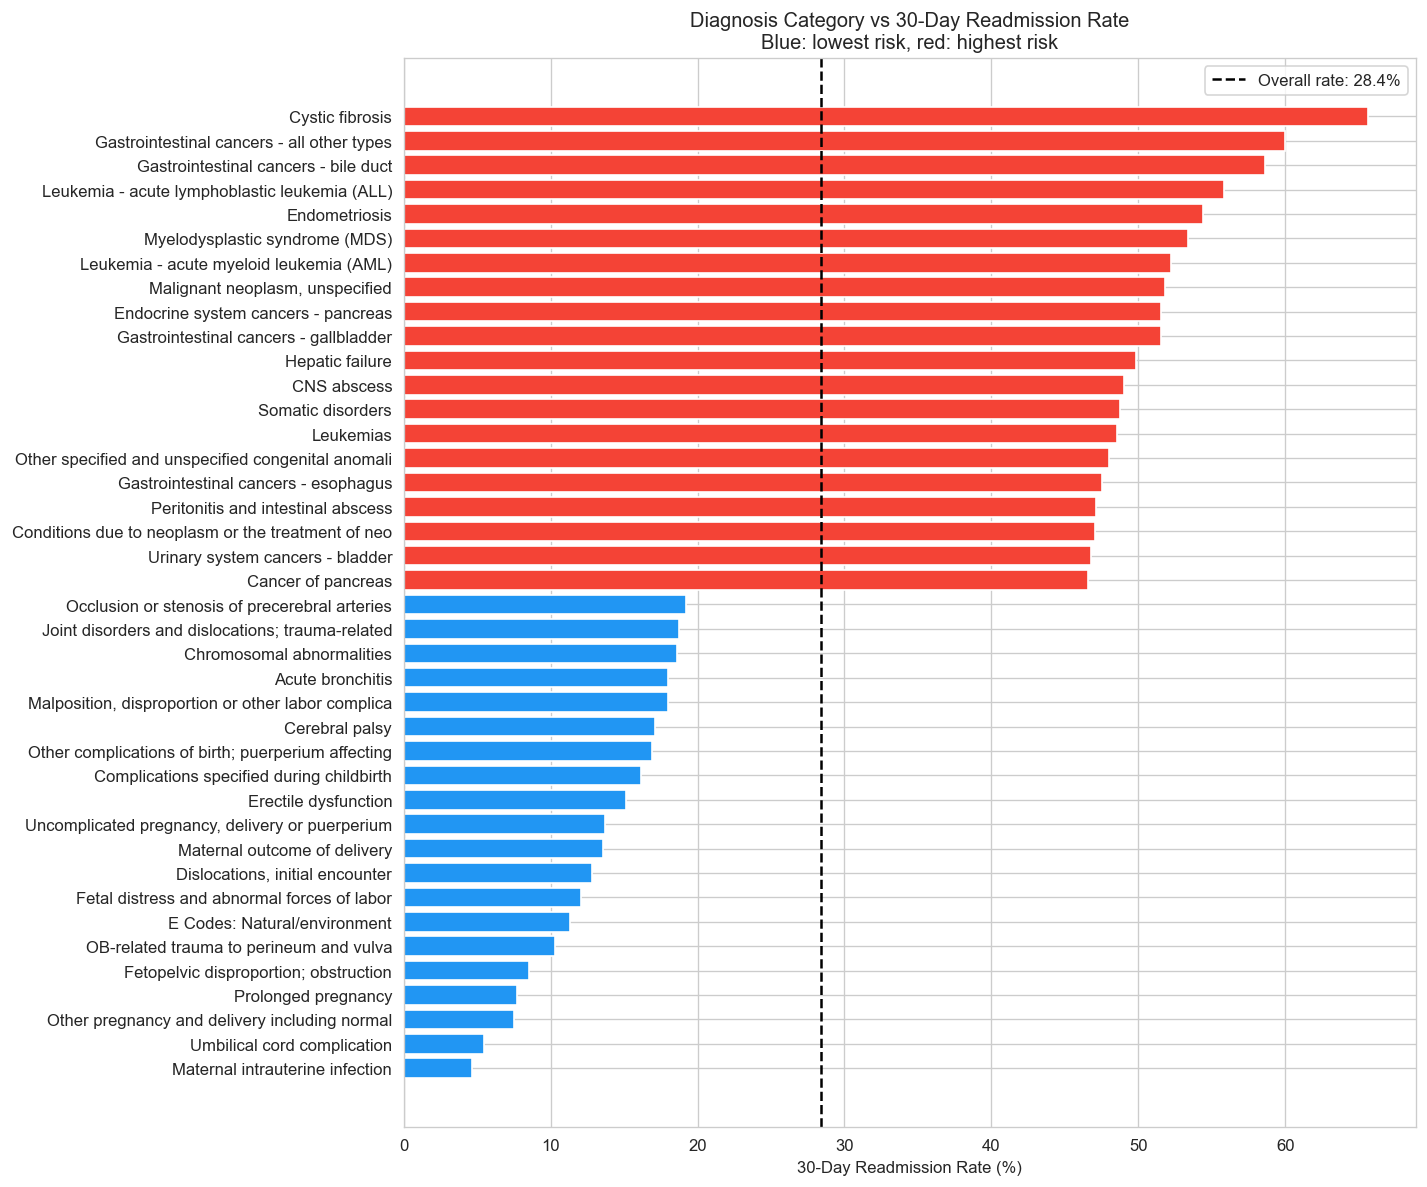


Bottom 5, lowest readmission risk:
  Maternal intrauterine infection: 4.6% (n=65)
  Umbilical cord complication: 5.4% (n=239)
  Other pregnancy and delivery including normal: 7.5% (n=1178)
  Prolonged pregnancy: 7.7% (n=78)
  Fetopelvic disproportion; obstruction: 8.5% (n=47)

Top 5, highest readmission risk:
  Endometriosis: 54.4% (n=57)
  Leukemia - acute lymphoblastic leukemia (ALL): 55.8% (n=77)
  Gastrointestinal cancers - bile duct: 58.7% (n=104)
  Gastrointestinal cancers - all other types: 60.0% (n=45)
  Cystic fibrosis: 65.6% (n=32)

Readmission rate range: 4.6% to 65.6%


In [57]:
print("="*80)
print("SECTION 4F: CLINICAL DIAGNOSIS CATEGORIES VS READMISSION RATE")
print("="*80)

# Use strict diagnosis detection: only columns saved from Section 5F.
# This excludes hadm_id variants, discharge_location_missing, and other non-diagnosis columns.

diag_cols = [c for c in df_features.columns
             if c in ccsr_diagnosis_cols or c in ccs_diagnosis_cols]

print(f"\nDiagnosis columns, CCSR + CCS: {len(diag_cols)}")

# Compute readmission rate for each diagnosis.
diag_rates = {}
for col in diag_cols:
    subset = df_features[df_features[col] == 1]
    if len(subset) >= 30:
        rate = subset['readmitted_30d'].mean()
        diag_rates[col] = {'rate': rate, 'n': len(subset)}

print(f"Categories with at least 30 patients: {len(diag_rates)}")

sorted_rates = sorted(diag_rates.items(), key=lambda x: x[1]['rate'])

if len(sorted_rates) >= 40:
    bottom_20 = sorted_rates[:20]
    top_20 = sorted_rates[-20:]
    plot_data = bottom_20 + top_20
else:
    plot_data = sorted_rates

labels = [x[0][:50] for x in plot_data]
rates = [x[1]['rate'] * 100 for x in plot_data]
split_point = min(20, len(plot_data) // 2)
colors = ['#2196F3'] * split_point + ['#F44336'] * (len(plot_data) - split_point)

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(labels, rates, color=colors)
overall_rate = df_features['readmitted_30d'].mean() * 100
ax.axvline(x=overall_rate, color='black', linestyle='--', linewidth=1.5,
           label=f"Overall rate: {overall_rate:.1f}%")
ax.set_xlabel("30-Day Readmission Rate (%)")
ax.set_title("Diagnosis Category vs 30-Day Readmission Rate\nBlue: lowest risk, red: highest risk")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nBottom 5, lowest readmission risk:")
for name, vals in sorted_rates[:5]:
    print(f"  {name}: {vals['rate']*100:.1f}% (n={vals['n']})")

print(f"\nTop 5, highest readmission risk:")
for name, vals in sorted_rates[-5:]:
    print(f"  {name}: {vals['rate']*100:.1f}% (n={vals['n']})")

if sorted_rates:
    rate_range = f"{sorted_rates[0][1]['rate']*100:.1f}% to {sorted_rates[-1][1]['rate']*100:.1f}%"
    print(f"\nReadmission rate range: {rate_range}")
else:
    print("\nNo diagnosis categories met the minimum patient threshold.")

print("="*80)

## Section 6: Preprocessing

### 6: Transform, Consolidate, Encode, and Prepare for Modeling

Input: df_features (60,946 x 822) from Section 5
Output: df_preprocessed (60,946 x ~450-500) ready for train/test split

### 6A: Create Missingness Indicator Flags
Binary flags created before imputation. Section 4E showed discharge_location missingness is correlated with readmission.

In [58]:
print("="*80)
print("SECTION 6A: CREATE MISSINGNESS INDICATOR FLAGS")
print("="*80)

df_prep = df_features.copy()

print(f"\nInput shape: {df_prep.shape}")
print("Creating missingness indicator flags BEFORE imputation...")

# Create flags for columns with significant missingness
# discharge_location: 25.1% missing (from Section 4E)
df_prep['discharge_location_missing'] = df_prep['discharge_location'].isna().astype(int)

# marital_status: 1.03% missing
df_prep['marital_status_missing'] = df_prep['marital_status'].isna().astype(int)

# insurance: 0.73% missing
df_prep['insurance_missing'] = df_prep['insurance'].isna().astype(int)

print(f"\nMissingness flags created:")
print(f"  discharge_location_missing: {df_prep['discharge_location_missing'].sum()} admissions")
print(f"  marital_status_missing: {df_prep['marital_status_missing'].sum()} admissions")
print(f"  insurance_missing: {df_prep['insurance_missing'].sum()} admissions")

SECTION 6A: CREATE MISSINGNESS INDICATOR FLAGS

Input shape: (60946, 722)
Creating missingness indicator flags BEFORE imputation...

Missingness flags created:
  discharge_location_missing: 15297 admissions
  marital_status_missing: 629 admissions
  insurance_missing: 444 admissions


### 6B: Winsorize Numeric Features
Extreme outliers are capped at the 99th percentile. Thresholds are los_days at 32 days and prior_admissions_count at 35.

In [59]:
print("\n" + "="*80)
print("SECTION 6B: WINSORIZE NUMERIC FEATURES AT 99TH PERCENTILE")
print("="*80)

# los_days: winsorize at 32 (from Section 4B findings)
print(f"\nlos_days before winsorization:")
print(f"  min: {df_prep['los_days'].min()}, max: {df_prep['los_days'].max()}")
print(f"  99th pct: {df_prep['los_days'].quantile(0.99):.1f}")

df_prep['los_days'] = df_prep['los_days'].clip(lower=0, upper=32)

print(f"los_days after winsorization at 32:")
print(f"  min: {df_prep['los_days'].min()}, max: {df_prep['los_days'].max()}")

# prior_admissions_count: winsorize at 35 (from Section 4B findings)
print(f"\nprior_admissions_count before winsorization:")
print(f"  min: {df_prep['prior_admissions_count'].min()}, max: {df_prep['prior_admissions_count'].max()}")
print(f"  99th pct: {df_prep['prior_admissions_count'].quantile(0.99):.1f}")

df_prep['prior_admissions_count'] = df_prep['prior_admissions_count'].clip(lower=0, upper=35)

print(f"prior_admissions_count after winsorization at 35:")
print(f"  min: {df_prep['prior_admissions_count'].min()}, max: {df_prep['prior_admissions_count'].max()}")


SECTION 6B: WINSORIZE NUMERIC FEATURES AT 99TH PERCENTILE

los_days before winsorization:
  min: -1, max: 295
  99th pct: 32.0
los_days after winsorization at 32:
  min: 0, max: 32

prior_admissions_count before winsorization:
  min: 0, max: 97
  99th pct: 35.0
prior_admissions_count after winsorization at 35:
  min: 0, max: 35


### 6C: Consolidate Race Categories
Race subcategories are consolidated to six groups for fairness analysis: WHITE, BLACK, ASIAN, HISPANIC, OTHER, and UNKNOWN.

In [60]:
print("\n" + "="*80)
print("SECTION 6C: CONSOLIDATE RACE TO 6 CATEGORIES")
print("="*80)

print(f"\nOriginal race categories ({df_prep['race'].nunique()}):")
print(df_prep['race'].value_counts())

# Define consolidation mapping
race_mapping = {
    'WHITE': 'WHITE',
    'BLACK/AFRICAN AMERICAN': 'BLACK',
    'ASIAN': 'ASIAN',
    'ASIAN - CHINESE': 'ASIAN',
    'ASIAN - INDIAN': 'ASIAN',
    'ASIAN - VIETNAMESE': 'ASIAN',
    'ASIAN - JAPANESE': 'ASIAN',
    'ASIAN - KOREAN': 'ASIAN',
    'ASIAN - CAMBODIAN': 'ASIAN',
    'ASIAN - THAI': 'ASIAN',
    'ASIAN - LAOTIAN': 'ASIAN',
    'ASIAN - PAKISTANI': 'ASIAN',
    'ASIAN - FILIPINO': 'ASIAN',
    'ASIAN - BANGLADESHI': 'ASIAN',
    'ASIAN - MALAYSIAN': 'ASIAN',
    'ASIAN - BURMESE': 'ASIAN',
    'ASIAN - ASIAN INDIAN': 'ASIAN',
    'HISPANIC/LATINO': 'HISPANIC',
    'HISPANIC/LATINO - PUERTO RICAN': 'HISPANIC',
    'HISPANIC/LATINO - DOMINICAN': 'HISPANIC',
    'HISPANIC/LATINO - MEXICAN': 'HISPANIC',
    'HISPANIC/LATINO - CUBAN': 'HISPANIC',
    'HISPANIC/LATINO - SALVADORAN': 'HISPANIC',
    'HISPANIC/LATINO - CENTRAL AMERICAN': 'HISPANIC',
    'HISPANIC/LATINO - COLOMBIAN': 'HISPANIC',
    'HISPANIC/LATINO - GUATEMALAN': 'HISPANIC',
    'HISPANIC/LATINO - HONDURAN': 'HISPANIC',
}

# Fill in any unmapped values as OTHER
df_prep['race_consolidated'] = df_prep['race'].map(race_mapping)
unmapped = df_prep['race_consolidated'].isna()
df_prep.loc[unmapped, 'race_consolidated'] = df_prep.loc[unmapped, 'race']

# Consolidate remaining to OTHER or UNKNOWN
other_races = df_prep[
    ~df_prep['race_consolidated'].isin(['WHITE', 'BLACK', 'ASIAN', 'HISPANIC'])
]['race_consolidated'].unique()
for race in other_races:
    if pd.isna(race):
        df_prep.loc[df_prep['race_consolidated'].isna(), 'race_consolidated'] = 'UNKNOWN'
    else:
        df_prep.loc[df_prep['race_consolidated'] == race, 'race_consolidated'] = 'OTHER'

print(f"\nConsolidated race categories (6):")
print(df_prep['race_consolidated'].value_counts())

# Drop original race column, keep consolidated
df_prep = df_prep.drop(columns=['race'])
df_prep = df_prep.rename(columns={'race_consolidated': 'race'})


SECTION 6C: CONSOLIDATE RACE TO 6 CATEGORIES

Original race categories (33):
race
WHITE                                        37880
BLACK/AFRICAN AMERICAN                        9366
OTHER                                         1993
WHITE - OTHER EUROPEAN                        1347
HISPANIC/LATINO - PUERTO RICAN                1282
HISPANIC OR LATINO                            1050
UNKNOWN                                        867
WHITE - RUSSIAN                                818
BLACK/CAPE VERDEAN                             768
ASIAN - CHINESE                                759
HISPANIC/LATINO - DOMINICAN                    728
ASIAN                                          600
BLACK/CARIBBEAN ISLAND                         516
BLACK/AFRICAN                                  362
HISPANIC/LATINO - GUATEMALAN                   314
WHITE - EASTERN EUROPEAN                       229
PATIENT DECLINED TO ANSWER                     214
HISPANIC/LATINO - SALVADORAN                   207

### 6D: Fill Missing Categorical Values
Missing categorical values are filled after flags are created. discharge_location and marital_status use UNKNOWN; insurance uses the mode.

In [61]:
print("\n" + "="*80)
print("SECTION 6D: FILL MISSING CATEGORICAL VALUES")
print("="*80)

# discharge_location: fill with 'UNKNOWN' (not 'HOME')
# Reason: missingness is predictive (different pattern from actual HOME)
missing_loc = df_prep['discharge_location'].isna().sum()
df_prep['discharge_location'] = df_prep['discharge_location'].fillna('UNKNOWN')
print(f"discharge_location: {missing_loc} rows filled with 'UNKNOWN'")

# marital_status: fill with 'UNKNOWN'
missing_mar = df_prep['marital_status'].isna().sum()
df_prep['marital_status'] = df_prep['marital_status'].fillna('UNKNOWN')
print(f"marital_status: {missing_mar} rows filled with 'UNKNOWN'")

# insurance: fill with mode
mode_insurance = df_prep['insurance'].mode()[0]
missing_ins = df_prep['insurance'].isna().sum()
df_prep['insurance'] = df_prep['insurance'].fillna(mode_insurance)
print(f"insurance: {missing_ins} rows filled with mode '{mode_insurance}'")

# language: fill with 'UNKNOWN' (if any missing)
if df_prep['language'].isna().sum() > 0:
    df_prep['language'] = df_prep['language'].fillna('UNKNOWN')
    print(f"language: {df_prep['language'].isna().sum()} rows filled")

print(f"\nFinal missing value check (categorical):")
categorical_cols = ['discharge_location', 'marital_status', 'insurance', 'language', 'admission_type', 'gender']
for col in categorical_cols:
    if col in df_prep.columns:
        print(f"  {col}: {df_prep[col].isna().sum()}")


SECTION 6D: FILL MISSING CATEGORICAL VALUES
discharge_location: 15297 rows filled with 'UNKNOWN'
marital_status: 629 rows filled with 'UNKNOWN'
insurance: 444 rows filled with mode 'Medicare'
language: 0 rows filled

Final missing value check (categorical):
  discharge_location: 0
  marital_status: 0
  insurance: 0
  language: 0
  admission_type: 0
  gender: 0


### 6E: Remove Near-Zero Variance Features
Diagnosis categories with less than 1% prevalence are dropped as low-information features.

In [122]:
print("\n" + "="*80)
print("SECTION 6E: REMOVE NEAR-ZERO VARIANCE FEATURES")
print("="*80)

# Identify CCSR and CCS columns (all diagnosis columns)
original_cols = {
    'subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime',
    'admission_type', 'admit_provider_id', 'admission_location',
    'discharge_location', 'insurance', 'language', 'marital_status',
    'race', 'edregtime', 'edouttime', 'hospital_expire_flag',
    'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod',
    'is_planned', 'age_group', 'next_admittime', 'next_is_planned',
    'days_to_next', 'is_last_admission', 'readmitted_30d', 'year',
    'prior_admissions_count', 'prior_bucket', 'los_days', 'came_via_ed',
    'discharge_location_missing', 'marital_status_missing', 'insurance_missing',
    'race_consolidated',
}

diagnosis_cols = [c for c in df_prep.columns if c not in original_cols]

print(f"Total diagnosis columns: {len(diagnosis_cols)}")

# Threshold: <1% prevalence (< 609 admissions with this diagnosis)
# 60,946 * 0.01 = 609.46
threshold = int(df_prep.shape[0] * 0.005)

low_variance_cols = []
for col in diagnosis_cols:
    n_positive = (df_prep[col] == 1).sum()
    if n_positive < threshold:
        low_variance_cols.append(col)

print(f"Threshold for near-zero variance: <{threshold} admissions (1%)")
print(f"Columns to drop: {len(low_variance_cols)}")

# Drop low variance columns
df_prep = df_prep.drop(columns=low_variance_cols)

print(f"\nAfter dropping near-zero variance:")
print(f"  Columns retained: {len(df_prep.columns)}")
print(f"  Diagnosis features remaining: {len([c for c in df_prep.columns if c not in original_cols])}")


SECTION 6E: REMOVE NEAR-ZERO VARIANCE FEATURES
Total diagnosis columns: 203
Threshold for near-zero variance: <304 admissions (1%)
Columns to drop: 0

After dropping near-zero variance:
  Columns retained: 239
  Diagnosis features remaining: 203


### 6F: One-Hot Encode Categorical Features
Categorical columns are encoded as binary dummy variables for modeling.

In [153]:
print("\n" + "="*80)
print("SECTION 6F: ONE-HOT ENCODE CATEGORICAL FEATURES")
print("="*80)

# Categorical columns to encode
categorical_to_encode = ['gender', 'race', 'admission_type', 'insurance',
                         'discharge_location', 'marital_status', 'language']

# Keep original columns for reference during split
original_id_cols = ['subject_id', 'hadm_id']

print(f"Encoding {len(categorical_to_encode)} categorical features...")

# One-hot encode with drop_first=False (keep all dummies)
df_encoded = pd.get_dummies(df_prep, columns=categorical_to_encode, drop_first=False, dtype='int8')

print(f"\nBefore encoding: {df_prep.shape[1]} columns")
print(f"After encoding: {df_encoded.shape[1]} columns")
print(f"New dummy columns added: {df_encoded.shape[1] - df_prep.shape[1]}")

# Handoff for downstream checkpoints, train/test split, and modeling.
df_preprocessed = df_encoded.copy()
print(f"df_preprocessed updated from df_encoded: {df_preprocessed.shape}")

# Show sample of encoded columns
encoded_cols = [c for c in df_encoded.columns if '_' in c and c not in df_prep.columns]
print(f"\nSample of encoded column names (first 15):")
print(encoded_cols[:15])


SECTION 6F: ONE-HOT ENCODE CATEGORICAL FEATURES
Encoding 7 categorical features...

Before encoding: 239 columns
After encoding: 298 columns
New dummy columns added: 59
df_preprocessed updated from df_encoded: (60946, 298)

Sample of encoded column names (first 15):
['gender_F', 'gender_M', 'race_ASIAN', 'race_BLACK', 'race_HISPANIC', 'race_OTHER', 'race_WHITE', 'admission_type_AMBULATORY OBSERVATION', 'admission_type_DIRECT EMER.', 'admission_type_DIRECT OBSERVATION', 'admission_type_ELECTIVE', 'admission_type_EU OBSERVATION', 'admission_type_EW EMER.', 'admission_type_OBSERVATION ADMIT', 'admission_type_SURGICAL SAME DAY ADMISSION']


In [154]:
print("\n" + "="*80)
print("SECTION 6G: PREPROCESSING CHECKPOINT")
print("="*80)

print(f"\ndf_preprocessed shape: {df_preprocessed.shape}")
print(f"Rows: {df_preprocessed.shape[0]:,}")
print(f"Columns: {df_preprocessed.shape[1]}")

nan_count = df_preprocessed.isna().sum().sum()
print(f"\nNaN check: {nan_count:,} total NaN values")

if nan_count > 0:
    print("\nColumns with NaN values, first 20:")
    nan_cols = df_preprocessed.columns[df_preprocessed.isna().any()].tolist()
    for col in nan_cols[:20]:
        col_nan = df_preprocessed[col].isna().sum()
        print(f"  {col}: {col_nan:,} NaN")
    if len(nan_cols) > 20:
        print(f"  Additional columns with NaN: {len(nan_cols) - 20}")
    print(f"\nNaN values must be resolved in Section 6H before Section 7.")
else:
    print("NaN check passed: 0 NaN values.")

print(f"\nTarget variable:")
vc = df_preprocessed['readmitted_30d'].value_counts().sort_index()
print(f"  Class 0: {vc.get(0, 0):,}")
print(f"  Class 1: {vc.get(1, 0):,}")
print(f"  Readmission rate: {df_preprocessed['readmitted_30d'].mean()*100:.1f}%")

print(f"\nPatients: {df_preprocessed['subject_id'].nunique():,}")
print(f"Admissions: {df_preprocessed['hadm_id'].nunique():,}")

if nan_count == 0:
    print(f"\nSection 6G complete. Proceed to Section 6H.")
else:
    print(f"\nSection 6G complete. Section 6H will resolve {nan_count:,} NaN values.")
print("="*80)


SECTION 6G: PREPROCESSING CHECKPOINT

df_preprocessed shape: (60946, 298)
Rows: 60,946
Columns: 298

NaN check: 143,087 total NaN values

Columns with NaN values, first 20:
  deathtime: 60,946 NaN
  edregtime: 20,465 NaN
  edouttime: 20,465 NaN
  dod: 41,211 NaN

NaN values must be resolved in Section 6H before Section 7.

Target variable:
  Class 0: 43,648
  Class 1: 17,298
  Readmission rate: 28.4%

Patients: 19,234
Admissions: 60,946

Section 6G complete. Section 6H will resolve 143,087 NaN values.


### 6H: Drop Non-Feature Columns and Verify Clean State
Date/time, leakage, and metadata columns are removed. Leakage columns (next_is_planned, days_to_next, is_last_admission) were used to construct the label and must never enter the feature matrix. hospital_expire_flag is an outcome, not a predictor.

In [156]:
print("\n" + "="*80)
print("SECTION 6H: DROP NON-FEATURE COLUMNS")
print("="*80)

print(f"\nInput: {df_preprocessed.shape}")
print(f"NaN count before: {df_preprocessed.isna().sum().sum():,}")

# Date and time columns are not model-ready numeric features.
datetime_cols = [
    'admittime', 'dischtime', 'deathtime',
    'edregtime', 'edouttime', 'next_admittime', 'dod'
]

# These columns were used to build the readmitted_30d label.
leakage_cols = [
    'next_is_planned',
    'days_to_next',
    'is_last_admission',
    'is_planned',
]

outcome_cols = ['hospital_expire_flag']

metadata_cols = [
    'anchor_year', 'anchor_year_group', 'year', 'age_group',
    'prior_bucket', 'admit_provider_id', 'admission_location',
]

all_drop = datetime_cols + leakage_cols + outcome_cols + metadata_cols
to_drop = [c for c in all_drop if c in df_preprocessed.columns]
not_found = [c for c in all_drop if c not in df_preprocessed.columns]

print(f"\nColumns to drop ({len(to_drop)}):")
for col in to_drop:
    print(f"  {col}")

if not_found:
    print(f"\nColumns not found, already absent: {not_found}")

df_preprocessed = df_preprocessed.drop(columns=to_drop, errors='ignore')

print(f"\nAfter dropping: {df_preprocessed.shape}")

remaining_nan = df_preprocessed.isna().sum().sum()
if remaining_nan > 0:
    print(f"\nResidual NaN: {remaining_nan:,}. Dropping columns that still contain NaN.")
    nan_cols = df_preprocessed.columns[df_preprocessed.isna().any()].tolist()
    print(f"  Dropping: {nan_cols}")
    df_preprocessed = df_preprocessed.drop(columns=nan_cols)

final_nan = df_preprocessed.isna().sum().sum()
print(f"\nFinal NaN count: {final_nan}")
assert final_nan == 0, f"ERROR: {final_nan} NaN values remain after cleanup."

required = ['subject_id', 'hadm_id', 'readmitted_30d']
for col in required:
    assert col in df_preprocessed.columns, f"ERROR: Required column {col!r} missing."

for col in leakage_cols + outcome_cols + datetime_cols:
    assert col not in df_preprocessed.columns, f"ERROR: Leakage or non-feature column {col!r} remains."

feature_cols = [c for c in df_preprocessed.columns
                if c not in ['subject_id', 'hadm_id', 'readmitted_30d']]

print(f"\nFinal df_preprocessed:")
print(f"  Shape: {df_preprocessed.shape}")
print(f"  Identifiers: 2, subject_id and hadm_id")
print(f"  Target: 1, readmitted_30d")
print(f"  Features: {len(feature_cols)}")
print(f"  NaN: {final_nan}")
print(f"  Unique patients: {df_preprocessed['subject_id'].nunique():,}")
print(f"  Readmission rate: {df_preprocessed['readmitted_30d'].mean()*100:.1f}%")

print(f"\nSection 6H complete. df_preprocessed is ready for Section 7.")
print("="*80)


SECTION 6H: DROP NON-FEATURE COLUMNS

Input: (60946, 279)
NaN count before: 0

Columns to drop (0):

Columns not found, already absent: ['admittime', 'dischtime', 'deathtime', 'edregtime', 'edouttime', 'next_admittime', 'dod', 'next_is_planned', 'days_to_next', 'is_last_admission', 'is_planned', 'hospital_expire_flag', 'anchor_year', 'anchor_year_group', 'year', 'age_group', 'prior_bucket', 'admit_provider_id', 'admission_location']

After dropping: (60946, 279)

Final NaN count: 0

Final df_preprocessed:
  Shape: (60946, 279)
  Identifiers: 2, subject_id and hadm_id
  Target: 1, readmitted_30d
  Features: 276
  NaN: 0
  Unique patients: 19,234
  Readmission rate: 28.4%

Section 6H complete. df_preprocessed is ready for Section 7.


## Section 7: Train/Test Split and Scaling

This section creates a patient-level train/test split, verifies that no patient appears in both sets, scales numeric features using train-only statistics, and saves the split artifacts for modeling.

### 7A: Prepare Data for Patient-Level Split

The target is separated from the feature matrix. Patient and admission identifiers are retained only for split logic and saved mappings, not as model features.

In [157]:
print("\n" + "="*80)
print("SECTION 7A: PREPARE DATA FOR PATIENT-LEVEL SPLIT")
print("="*80)

# Verify input.
print(f"\nInput: df_preprocessed")
print(f"  Shape: {df_preprocessed.shape}")
print(f"  NaN: {df_preprocessed.isna().sum().sum()}")
assert df_preprocessed.isna().sum().sum() == 0, "NaN found in df_preprocessed."

required_cols = ['subject_id', 'hadm_id', 'readmitted_30d']
for col in required_cols:
    assert col in df_preprocessed.columns, f"Required column {col!r} missing from df_preprocessed."

# Separate X features and y target.
# Keep subject_id and hadm_id for split logic but exclude them from model features.
feature_cols = [c for c in df_preprocessed.columns
                if c not in ['subject_id', 'hadm_id', 'readmitted_30d']]

X = df_preprocessed[['subject_id', 'hadm_id'] + feature_cols].copy()
y = df_preprocessed['readmitted_30d'].astype(int).copy()

print(f"\nX, features plus IDs: {X.shape}")
print(f"  Columns: subject_id, hadm_id, plus {len(feature_cols)} features")

print(f"\ny, target: {y.shape}")
print(f"  Class 0: {(y == 0).sum():,} ({(y == 0).sum() / len(y) * 100:.1f}%)")
print(f"  Class 1: {(y == 1).sum():,} ({(y == 1).sum() / len(y) * 100:.1f}%)")

# Patient-level label for stratification.
# If a patient has any readmission-positive admission, their patient label is 1.
patient_max_status = df_preprocessed.groupby('subject_id')['readmitted_30d'].max()
print(f"\nUnique patients: {len(patient_max_status):,}")
print(f"  Patient-level positive rate: {patient_max_status.mean()*100:.1f}%")

# Numeric columns for scaling. All dummy-encoded columns remain unchanged.
numeric_cols = ['anchor_age', 'prior_admissions_count', 'los_days']
numeric_cols_exist = [c for c in numeric_cols if c in X.columns]
print(f"\nNumeric columns to scale: {numeric_cols_exist}")


SECTION 7A: PREPARE DATA FOR PATIENT-LEVEL SPLIT

Input: df_preprocessed
  Shape: (60946, 279)
  NaN: 0

X, features plus IDs: (60946, 278)
  Columns: subject_id, hadm_id, plus 276 features

y, target: (60946,)
  Class 0: 43,648 (71.6%)
  Class 1: 17,298 (28.4%)

Unique patients: 19,234
  Patient-level positive rate: 42.2%

Numeric columns to scale: ['anchor_age', 'prior_admissions_count', 'los_days']


In [158]:
print("\n" + "="*80)
print("SECTION 7B: PATIENT-LEVEL 80/20 STRATIFIED SPLIT")
print("="*80)

from sklearn.model_selection import train_test_split

# Split by patient, not by row.
# This prevents admissions from the same patient from appearing in both train and test.

patient_ids = patient_max_status.index.values
patient_labels = patient_max_status.values

train_patient_ids, test_patient_ids = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=SEED,
    stratify=patient_labels
)

print(f"\nPatient split:")
print(f"  Train patients: {len(train_patient_ids):,} ({len(train_patient_ids)/len(patient_ids)*100:.1f}%)")
print(f"  Test patients: {len(test_patient_ids):,} ({len(test_patient_ids)/len(patient_ids)*100:.1f}%)")

train_mask = X['subject_id'].isin(train_patient_ids)
test_mask = X['subject_id'].isin(test_patient_ids)

X_train = X[train_mask].copy()
X_test = X[test_mask].copy()
y_train = y[train_mask].copy()
y_test = y[test_mask].copy()

print(f"\nAdmission split, rows:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test: {y_test.shape}")

assert len(X_train) + len(X_test) == len(X), "Train and test row counts do not sum to total rows."
assert len(y_train) == len(X_train), "y_train length does not match X_train."
assert len(y_test) == len(X_test), "y_test length does not match X_test."

print(f"\nClass balance:")
print(f"  Overall: {y.mean()*100:.1f}% readmission")
print(f"  Train:   {y_train.mean()*100:.1f}% readmission")
print(f"  Test:    {y_test.mean()*100:.1f}% readmission")


SECTION 7B: PATIENT-LEVEL 80/20 STRATIFIED SPLIT

Patient split:
  Train patients: 15,387 (80.0%)
  Test patients: 3,847 (20.0%)

Admission split, rows:
  X_train: (48559, 278)
  X_test: (12387, 278)
  y_train: (48559,)
  y_test: (12387,)

Class balance:
  Overall: 28.4% readmission
  Train:   28.5% readmission
  Test:    27.8% readmission


In [159]:
print("\n" + "="*80)
print("SECTION 7C: ASSERT ZERO PATIENT OVERLAP")
print("="*80)

train_patients_set = set(X_train['subject_id'].unique())
test_patients_set = set(X_test['subject_id'].unique())

overlap = train_patients_set & test_patients_set

print(f"\nPatient overlap check:")
print(f"  Train patients: {len(train_patients_set):,}")
print(f"  Test patients: {len(test_patients_set):,}")
print(f"  Overlapping patients: {len(overlap)}")

assert len(overlap) == 0, (
    f"DATA LEAKAGE: Found {len(overlap)} patients in both train and test sets: "
    f"{list(overlap)[:5]}"
)

print(f"\nZero overlap confirmed. Train and test are completely independent at the patient level.")


SECTION 7C: ASSERT ZERO PATIENT OVERLAP

Patient overlap check:
  Train patients: 15,387
  Test patients: 3,847
  Overlapping patients: 0

Zero overlap confirmed. Train and test are completely independent at the patient level.


In [160]:
print("\n" + "="*80)
print("SECTION 7D: STANDARDSCALER, FIT ON TRAIN ONLY")
print("="*80)

from sklearn.preprocessing import StandardScaler
import pickle

outputs_dir = PROJECT_ROOT / 'outputs'
outputs_dir.mkdir(exist_ok=True)

numeric_to_scale = [c for c in numeric_cols_exist if c in X_train.columns]

print(f"\nNumeric columns to scale: {numeric_to_scale}")

train_ids = X_train[['subject_id', 'hadm_id']].copy()
test_ids = X_test[['subject_id', 'hadm_id']].copy()

X_train_features = X_train.drop(columns=['subject_id', 'hadm_id'])
X_test_features = X_test.drop(columns=['subject_id', 'hadm_id'])

print(f"\nBefore scaling:")
print(f"  X_train_features: {X_train_features.shape}")
print(f"  X_test_features: {X_test_features.shape}")

scaler = StandardScaler()
if numeric_to_scale:
    scaler.fit(X_train_features[numeric_to_scale])

    X_train_features.loc[:, numeric_to_scale] = scaler.transform(X_train_features[numeric_to_scale])
    X_test_features.loc[:, numeric_to_scale] = scaler.transform(X_test_features[numeric_to_scale])

    print(f"\nScaler fit on train only. Transformed both sets with train statistics.")
    for i, col in enumerate(numeric_to_scale):
        print(f"  {col}: mean={scaler.mean_[i]:.2f}, std={scaler.scale_[i]:.2f}")
else:
    print(f"\nNo numeric columns to scale. All features are binary or categorical indicators.")

print(f"\nAfter scaling:")
print(f"  X_train_features: {X_train_features.shape}")
print(f"  X_test_features: {X_test_features.shape}")

assert X_train_features.shape[1] == len(feature_cols), "Unexpected train feature count after dropping IDs."
assert X_test_features.shape[1] == len(feature_cols), "Unexpected test feature count after dropping IDs."

scaler_path = outputs_dir / 'capstone_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"\nSaved scaler to {scaler_path}")


SECTION 7D: STANDARDSCALER, FIT ON TRAIN ONLY

Numeric columns to scale: ['anchor_age', 'prior_admissions_count', 'los_days']

Before scaling:
  X_train_features: (48559, 276)
  X_test_features: (12387, 276)

Scaler fit on train only. Transformed both sets with train statistics.
  anchor_age: mean=58.02, std=17.84
  prior_admissions_count: mean=3.86, std=6.15
  los_days: mean=4.07, std=5.39

After scaling:
  X_train_features: (48559, 276)
  X_test_features: (12387, 276)

Saved scaler to C:\Users\dhara\OneDrive\Desktop\Project 1\outputs\capstone_scaler.pkl


In [161]:
print("\n" + "="*80)
print("SECTION 7E: SAVE SPLITS TO DISK")
print("="*80)

outputs_dir = PROJECT_ROOT / 'outputs'
outputs_dir.mkdir(exist_ok=True)

X_train_path = outputs_dir / 'capstone_X_train.parquet'
X_test_path = outputs_dir / 'capstone_X_test.parquet'

X_train_features.to_parquet(X_train_path, index=False)
X_test_features.to_parquet(X_test_path, index=False)

print(f"\nSaved X_train: {X_train_path}")
print(f"  Shape: {X_train_features.shape}")
print(f"  Size: {X_train_path.stat().st_size / 1024 / 1024:.1f} MB")

print(f"\nSaved X_test: {X_test_path}")
print(f"  Shape: {X_test_features.shape}")
print(f"  Size: {X_test_path.stat().st_size / 1024 / 1024:.1f} MB")

y_train_path = outputs_dir / 'capstone_y_train.csv'
y_test_path = outputs_dir / 'capstone_y_test.csv'

y_train.to_csv(y_train_path, index=False, header=True)
y_test.to_csv(y_test_path, index=False, header=True)

print(f"\nSaved y_train: {y_train_path}")
print(f"  Shape: {y_train.shape}")
print(f"  Readmission rate: {y_train.mean()*100:.1f}%")

print(f"\nSaved y_test: {y_test_path}")
print(f"  Shape: {y_test.shape}")
print(f"  Readmission rate: {y_test.mean()*100:.1f}%")

train_ids_path = outputs_dir / 'capstone_train_ids.csv'
test_ids_path = outputs_dir / 'capstone_test_ids.csv'

train_ids.to_csv(train_ids_path, index=False)
test_ids.to_csv(test_ids_path, index=False)

print(f"\nSaved train patient IDs: {train_ids_path}")
print(f"Saved test patient IDs: {test_ids_path}")

saved_paths = [
    X_train_path, X_test_path, y_train_path, y_test_path,
    scaler_path, train_ids_path, test_ids_path
]

for path in saved_paths:
    assert path.exists(), f"Expected output file was not created: {path}"
    assert path.stat().st_size > 0, f"Output file is empty: {path}"

print(f"\nAll splits saved to {outputs_dir}")


SECTION 7E: SAVE SPLITS TO DISK

Saved X_train: C:\Users\dhara\OneDrive\Desktop\Project 1\outputs\capstone_X_train.parquet
  Shape: (48559, 276)
  Size: 1.0 MB

Saved X_test: C:\Users\dhara\OneDrive\Desktop\Project 1\outputs\capstone_X_test.parquet
  Shape: (12387, 276)
  Size: 0.4 MB

Saved y_train: C:\Users\dhara\OneDrive\Desktop\Project 1\outputs\capstone_y_train.csv
  Shape: (48559,)
  Readmission rate: 28.5%

Saved y_test: C:\Users\dhara\OneDrive\Desktop\Project 1\outputs\capstone_y_test.csv
  Shape: (12387,)
  Readmission rate: 27.8%

Saved train patient IDs: C:\Users\dhara\OneDrive\Desktop\Project 1\outputs\capstone_train_ids.csv
Saved test patient IDs: C:\Users\dhara\OneDrive\Desktop\Project 1\outputs\capstone_test_ids.csv

All splits saved to C:\Users\dhara\OneDrive\Desktop\Project 1\outputs


In [162]:
print("\n" + "="*80)
print("SECTION 7F: FINAL CHECKPOINT")
print("="*80)

final_overlap = train_patients_set & test_patients_set

print(f"""
TRAIN/TEST SPLIT SUMMARY
========================

Patient-level split:
  Total patients: {len(patient_max_status):,}
  Train patients: {len(train_patient_ids):,} ({len(train_patient_ids)/len(patient_max_status)*100:.1f}%)
  Test patients: {len(test_patient_ids):,} ({len(test_patient_ids)/len(patient_max_status)*100:.1f}%)
  Patient overlap: {len(final_overlap)} (must be 0)

Admission-level split:
  Total admissions: {len(X):,}
  Train admissions: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)
  Test admissions: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)

Class balance:
  Overall readmission rate: {y.mean()*100:.1f}%
  Train readmission rate: {y_train.mean()*100:.1f}%
  Test readmission rate: {y_test.mean()*100:.1f}%

Features:
  Total features: {X_train_features.shape[1]}
  Numeric scaled: {len(numeric_to_scale)}
  Binary/categorical: {X_train_features.shape[1] - len(numeric_to_scale)}

Data leakage prevention:
  Patient overlap: {len(final_overlap)} (must be 0)
  Scaler fit on: train only
  Feature scaling: StandardScaler with train statistics

Files saved:
  capstone_X_train.parquet
  capstone_X_test.parquet
  capstone_y_train.csv
  capstone_y_test.csv
  capstone_scaler.pkl
  capstone_train_ids.csv
  capstone_test_ids.csv
""")

assert len(final_overlap) == 0, "FINAL CHECK FAILED: Patient overlap detected."

for path in saved_paths:
    assert path.exists(), f"FINAL CHECK FAILED: Missing output file {path}"
    assert path.stat().st_size > 0, f"FINAL CHECK FAILED: Empty output file {path}"

print("Section 7 complete. Ready for Section 8, Modeling.")
print("="*80)


SECTION 7F: FINAL CHECKPOINT

TRAIN/TEST SPLIT SUMMARY

Patient-level split:
  Total patients: 19,234
  Train patients: 15,387 (80.0%)
  Test patients: 3,847 (20.0%)
  Patient overlap: 0 (must be 0)

Admission-level split:
  Total admissions: 60,946
  Train admissions: 48,559 (79.7%)
  Test admissions: 12,387 (20.3%)

Class balance:
  Overall readmission rate: 28.4%
  Train readmission rate: 28.5%
  Test readmission rate: 27.8%

Features:
  Total features: 276
  Numeric scaled: 3
  Binary/categorical: 273

Data leakage prevention:
  Patient overlap: 0 (must be 0)
  Scaler fit on: train only
  Feature scaling: StandardScaler with train statistics

Files saved:
  capstone_X_train.parquet
  capstone_X_test.parquet
  capstone_y_train.csv
  capstone_y_test.csv
  capstone_scaler.pkl
  capstone_train_ids.csv
  capstone_test_ids.csv

Section 7 complete. Ready for Section 8, Modeling.


## Section 8: Model Training and Evaluation

This section trains 10 predictive supervised models, including one soft-voting ensemble, plus one unsupervised K-Means clustering model. All predictive models are evaluated on the same held-out patient-level test set using AUROC, AUPRC, F1, precision, and recall.

### 8A: Load and Verify Data

The train/test artifacts from Section 7 are loaded from disk. These splits were created at the patient level to prevent leakage across train and test sets.

In [163]:
print("\n" + "="*80)
print("SECTION 8A: LOAD AND VERIFY TRAIN/TEST SPLITS")
print("="*80)

import pandas as pd
import numpy as np
import pickle
from pathlib import Path

X_train = pd.read_parquet(PROJECT_ROOT / 'outputs' / 'capstone_X_train.parquet')
X_test = pd.read_parquet(PROJECT_ROOT / 'outputs' / 'capstone_X_test.parquet')
y_train = pd.read_csv(PROJECT_ROOT / 'outputs' / 'capstone_y_train.csv').iloc[:, 0].astype(int)
y_test = pd.read_csv(PROJECT_ROOT / 'outputs' / 'capstone_y_test.csv').iloc[:, 0].astype(int)

assert X_train.shape[0] == 48559, f"X_train row count mismatch: {X_train.shape}"
assert X_test.shape[0] == 12387, f"X_test row count mismatch: {X_test.shape}"
assert X_train.shape[1] == X_test.shape[1], f"Train/test feature count mismatch: {X_train.shape} vs {X_test.shape}"
assert X_train.shape[1] > 186, f"Expected encoded feature count to exceed old 186-feature set, found {X_train.shape[1]}"
assert y_train.shape == (48559,), f"y_train shape mismatch: {y_train.shape}"
assert y_test.shape == (12387,), f"y_test shape mismatch: {y_test.shape}"
assert X_train.isna().sum().sum() == 0, "NaN found in X_train."
assert X_test.isna().sum().sum() == 0, "NaN found in X_test."

print(f"\nData loaded successfully:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test: {y_test.shape}")

print(f"\nClass balance:")
print(f"  Train: {y_train.mean()*100:.1f}% readmission ({int(y_train.sum()):,} positive)")
print(f"  Test: {y_test.mean()*100:.1f}% readmission ({int(y_test.sum()):,} positive)")

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight for tree models: {scale_pos_weight:.2f}")

metrics_dict = {}
model_objects = {}
y_pred_proba_dict = {}
y_pred_dict = {}


SECTION 8A: LOAD AND VERIFY TRAIN/TEST SPLITS

Data loaded successfully:
  X_train: (48559, 276)
  X_test: (12387, 276)
  y_train: (48559,)
  y_test: (12387,)

Class balance:
  Train: 28.5% readmission (13,856 positive)
  Test: 27.8% readmission (3,442 positive)

scale_pos_weight for tree models: 2.50


### 8B: Group A - Baseline Models

Baseline supervised models provide interpretable and fast reference points: Decision Tree, Logistic Regression, and Gaussian Naive Bayes.

In [164]:
print("\n" + "="*80)
print("SECTION 8B-1: DECISION TREE, max_depth=5")
print("="*80)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score

dt = DecisionTreeClassifier(max_depth=5, random_state=SEED, class_weight='balanced')
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_pred_proba = dt.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Decision Tree Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['Decision Tree'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['Decision Tree'] = dt
y_pred_proba_dict['Decision Tree'] = y_pred_proba
y_pred_dict['Decision Tree'] = y_pred


SECTION 8B-1: DECISION TREE, max_depth=5
Decision Tree Results, threshold=0.5:
  ROC-AUC: 0.6115
  AUPRC: 0.3577
  F1: 0.4416
  Precision: 0.3393
  Recall: 0.6325


In [165]:
print("\n" + "="*80)
print("SECTION 8B-2: LOGISTIC REGRESSION, class_weight='balanced'")
print("="*80)

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Logistic Regression Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['Logistic Regression'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['Logistic Regression'] = lr
y_pred_proba_dict['Logistic Regression'] = y_pred_proba
y_pred_dict['Logistic Regression'] = y_pred


SECTION 8B-2: LOGISTIC REGRESSION, class_weight='balanced'
Logistic Regression Results, threshold=0.5:
  ROC-AUC: 0.6525
  AUPRC: 0.4103
  F1: 0.4536
  Precision: 0.3839
  Recall: 0.5543


In [166]:
print("\n" + "="*80)
print("SECTION 8B-3: NAIVE BAYES, GaussianNB")
print("="*80)

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)
y_pred_proba = nb_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Naive Bayes Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['Naive Bayes'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['Naive Bayes'] = nb_model
y_pred_proba_dict['Naive Bayes'] = y_pred_proba
y_pred_dict['Naive Bayes'] = y_pred


SECTION 8B-3: NAIVE BAYES, GaussianNB
Naive Bayes Results, threshold=0.5:
  ROC-AUC: 0.6072
  AUPRC: 0.3514
  F1: 0.4443
  Precision: 0.3370
  Recall: 0.6519


### 8C: Group B - Ensemble Tree Methods

Tree ensemble models capture nonlinear relationships and feature interactions: Random Forest, AdaBoost, Gradient Boosting, and XGBoost.

In [ ]:
print("\n" + "="*80)
print("SECTION 8C-1: RANDOM FOREST, n_estimators=100")
print("="*80)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100, max_depth=15, random_state=SEED,
    class_weight='balanced', n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Random Forest Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['Random Forest'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['Random Forest'] = rf
y_pred_proba_dict['Random Forest'] = y_pred_proba
y_pred_dict['Random Forest'] = y_pred


SECTION 8C-1: RANDOM FOREST, n_estimators=100
Random Forest Results, threshold=0.5:
  ROC-AUC: 0.6425
  AUPRC: 0.3939
  F1: 0.4180
  Precision: 0.3868
  Recall: 0.4547


In [169]:
print("\n" + "="*80)
print("SECTION 8C-2: ADABOOST, n_estimators=100")
print("="*80)

from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, random_state=SEED)
ada.fit(X_train, y_train)

y_pred = ada.predict(X_test)
y_pred_proba = ada.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"AdaBoost Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['AdaBoost'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['AdaBoost'] = ada
y_pred_proba_dict['AdaBoost'] = y_pred_proba
y_pred_dict['AdaBoost'] = y_pred


SECTION 8C-2: ADABOOST, n_estimators=100
AdaBoost Results, threshold=0.5:
  ROC-AUC: 0.6519
  AUPRC: 0.4043
  F1: 0.1896
  Precision: 0.4874
  Recall: 0.1177


In [170]:
print("\n" + "="*80)
print("SECTION 8C-3: GRADIENT BOOSTING, max_depth=4")
print("="*80)

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(max_depth=4, n_estimators=100, random_state=SEED)
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)
y_pred_proba = gb.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Gradient Boosting Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['Gradient Boosting'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['Gradient Boosting'] = gb
y_pred_proba_dict['Gradient Boosting'] = y_pred_proba
y_pred_dict['Gradient Boosting'] = y_pred


SECTION 8C-3: GRADIENT BOOSTING, max_depth=4
Gradient Boosting Results, threshold=0.5:
  ROC-AUC: 0.6541
  AUPRC: 0.4130
  F1: 0.1494
  Precision: 0.5551
  Recall: 0.0863


In [171]:
print("\n" + "="*80)
print("SECTION 8C-4: XGBOOST, PRIMARY MODEL")
print("="*80)

import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_lambda=1,
    reg_alpha=0.5,
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    random_state=SEED,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train, verbose=False)

y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = xgb_model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"XGBoost Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

thresholds = np.arange(0.3, 0.8, 0.05)
f1_scores = []
for threshold in thresholds:
    y_pred_thresh = (y_pred_proba >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"\nExploratory best F1 threshold: {best_threshold:.2f}. Official metrics use threshold 0.5.")

y_train_pred_proba = xgb_model.predict_proba(X_train)[:, 1]
train_roc_auc = roc_auc_score(y_train, y_train_pred_proba)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
gap = train_roc_auc - test_roc_auc

print(f"\nOverfitting check:")
print(f"  Train ROC-AUC: {train_roc_auc:.4f}")
print(f"  Test ROC-AUC: {test_roc_auc:.4f}")
print(f"  Gap: {gap:.4f}")

metrics_dict['XGBoost'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['XGBoost'] = xgb_model
y_pred_proba_dict['XGBoost'] = y_pred_proba
y_pred_dict['XGBoost'] = y_pred


SECTION 8C-4: XGBOOST, PRIMARY MODEL
XGBoost Results, threshold=0.5:
  ROC-AUC: 0.6501
  AUPRC: 0.4042
  F1: 0.4490
  Precision: 0.3859
  Recall: 0.5366

Exploratory best F1 threshold: 0.40. Official metrics use threshold 0.5.

Overfitting check:
  Train ROC-AUC: 0.7586
  Test ROC-AUC: 0.6501
  Gap: 0.1085


### 8D: Group C - Distance-Based Model

K-Nearest Neighbors is included as a distance-based supervised model. It uses the scaled numeric features from Section 7.

In [172]:
print("\n" + "="*80)
print("SECTION 8D: K-NEAREST NEIGHBORS, k=5, weights='distance'")
print("="*80)

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
y_pred_proba = knn.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"KNN Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['KNN'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['KNN'] = knn
y_pred_proba_dict['KNN'] = y_pred_proba
y_pred_dict['KNN'] = y_pred


SECTION 8D: K-NEAREST NEIGHBORS, k=5, weights='distance'
KNN Results, threshold=0.5:
  ROC-AUC: 0.5798
  AUPRC: 0.3420
  F1: 0.2429
  Precision: 0.3872
  Recall: 0.1769


### 8E: Group D - Extra Trees Classifier

Extra Trees adds a ninth base supervised model and provides a randomized tree-ensemble comparison to Random Forest.

In [173]:
print("\n" + "="*80)
print("SECTION 8E: EXTRA TREES CLASSIFIER, n_estimators=100")
print("="*80)

from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=100, max_depth=15, random_state=SEED,
    class_weight='balanced', n_jobs=-1
)
et.fit(X_train, y_train)

y_pred = et.predict(X_test)
y_pred_proba = et.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Extra Trees Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['Extra Trees'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['Extra Trees'] = et
y_pred_proba_dict['Extra Trees'] = y_pred_proba
y_pred_dict['Extra Trees'] = y_pred


SECTION 8E: EXTRA TREES CLASSIFIER, n_estimators=100
Extra Trees Results, threshold=0.5:
  ROC-AUC: 0.6402
  AUPRC: 0.3966
  F1: 0.4345
  Precision: 0.3844
  Recall: 0.4997


### 8F: Group E - Unsupervised Model

K-Means is fit on training features only, then used to assign test admissions to clusters for exploratory subgroup analysis.

In [174]:
print("\n" + "="*80)
print("SECTION 8F: K-MEANS, k=3, UNSUPERVISED CLUSTERING")
print("="*80)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
kmeans.fit(X_train)

clusters_test = kmeans.predict(X_test)

print(f"K-Means Clustering, k=3:")
print(f"  Fit on: training data ({X_train.shape[0]:,} admissions)")
print(f"  Predicted on: test data ({X_test.shape[0]:,} admissions)")
print(f"\nTest admissions assigned to clusters: {np.bincount(clusters_test)}")
print(f"\nReadmission rate by cluster:")

cluster_readmission = {}
for cluster_id in range(3):
    mask = clusters_test == cluster_id
    rate = y_test[mask].mean() if mask.sum() > 0 else np.nan
    count = mask.sum()
    print(f"  Cluster {cluster_id}: {count:,} admissions, {rate*100:.1f}% readmission")
    cluster_readmission[cluster_id] = (count, rate)

print(f"\nKey insight: K-Means identifies natural patient subgroups.")
print(f"Clusters may represent severity levels or clinical phenotypes.")
print(f"Clinical interpretation requires domain review.")

model_objects['K-Means'] = kmeans


SECTION 8F: K-MEANS, k=3, UNSUPERVISED CLUSTERING
K-Means Clustering, k=3:
  Fit on: training data (48,559 admissions)
  Predicted on: test data (12,387 admissions)

Test admissions assigned to clusters: [5129 4714 2544]

Readmission rate by cluster:
  Cluster 0: 5,129 admissions, 24.4% readmission
  Cluster 1: 4,714 admissions, 25.8% readmission
  Cluster 2: 2,544 admissions, 38.3% readmission

Key insight: K-Means identifies natural patient subgroups.
Clusters may represent severity levels or clinical phenotypes.
Clinical interpretation requires domain review.


### 8G: Ensemble - Voting Classifier

The soft-voting ensemble combines the probability estimates from XGBoost, Gradient Boosting, and Random Forest. It is fit on training data before test-set prediction.

In [175]:
print("\n" + "="*80)
print("SECTION 8G: ENSEMBLE, VOTINGCLASSIFIER, SOFT VOTING")
print("="*80)

from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('xgb', model_objects['XGBoost']),
        ('gb', model_objects['Gradient Boosting']),
        ('rf', model_objects['Random Forest'])
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)

y_pred_proba = voting_clf.predict_proba(X_test)[:, 1]
y_pred = voting_clf.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Ensemble VotingClassifier Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['Ensemble (Voting)'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['Ensemble (Voting)'] = voting_clf
y_pred_proba_dict['Ensemble (Voting)'] = y_pred_proba
y_pred_dict['Ensemble (Voting)'] = y_pred


SECTION 8G: ENSEMBLE, VOTINGCLASSIFIER, SOFT VOTING
Ensemble VotingClassifier Results, threshold=0.5:
  ROC-AUC: 0.6586
  AUPRC: 0.4135
  F1: 0.3607
  Precision: 0.4475
  Recall: 0.3021


### 8H: Model Evaluation and Comparison

All predictive models are compared with the same held-out test set and the same default 0.5 classification threshold. ROC and calibration curves are shown inline.

In [176]:
print("\n" + "="*80)
print("SECTION 8H-1: VERIFY METRICS FOR ALL PREDICTIVE MODELS")
print("="*80)

required_models = [
    'Decision Tree', 'Logistic Regression', 'Naive Bayes',
    'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost',
    'KNN', 'Extra Trees', 'Ensemble (Voting)'
]

missing_models = [m for m in required_models if m not in metrics_dict]
assert not missing_models, f"Missing model metrics: {missing_models}"

for model_name in required_models:
    for metric in ['ROC-AUC', 'AUPRC', 'F1', 'Precision', 'Recall']:
        value = metrics_dict[model_name][metric]
        assert 0 <= value <= 1, f"{model_name} {metric} out of range: {value}"

print(f"Verified metrics for {len(required_models)} predictive models.")
print("Metrics: ROC-AUC, AUPRC, F1, precision, recall.")


SECTION 8H-1: VERIFY METRICS FOR ALL PREDICTIVE MODELS
Verified metrics for 10 predictive models.
Metrics: ROC-AUC, AUPRC, F1, precision, recall.


In [177]:
print("\n" + "="*80)
print("SECTION 8H-2: MODEL COMPARISON TABLE, threshold=0.5")
print("="*80)

results_df = pd.DataFrame.from_dict(metrics_dict, orient='index')
results_df = results_df[['ROC-AUC', 'AUPRC', 'F1', 'Precision', 'Recall']]
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("\nALL PREDICTIVE MODELS, PERFORMANCE METRICS")
print(results_df.round(4).to_string())

print(f"\nBest model by ROC-AUC: {results_df.index[0]} ({results_df['ROC-AUC'].iloc[0]:.4f})")
print(f"Best model by AUPRC: {results_df['AUPRC'].idxmax()} ({results_df['AUPRC'].max():.4f})")
print(f"Best model by F1: {results_df['F1'].idxmax()} ({results_df['F1'].max():.4f})")

best_model_name = results_df.index[0]
best_model_auc = results_df['ROC-AUC'].iloc[0]


SECTION 8H-2: MODEL COMPARISON TABLE, threshold=0.5

ALL PREDICTIVE MODELS, PERFORMANCE METRICS
                     ROC-AUC   AUPRC      F1  Precision  Recall
Ensemble (Voting)     0.6586  0.4135  0.3607     0.4475  0.3021
Gradient Boosting     0.6541  0.4130  0.1494     0.5551  0.0863
Logistic Regression   0.6525  0.4103  0.4536     0.3839  0.5543
AdaBoost              0.6519  0.4043  0.1896     0.4874  0.1177
XGBoost               0.6501  0.4042  0.4490     0.3859  0.5366
Random Forest         0.6425  0.3939  0.4180     0.3868  0.4547
Extra Trees           0.6402  0.3966  0.4345     0.3844  0.4997
Decision Tree         0.6115  0.3577  0.4416     0.3393  0.6325
Naive Bayes           0.6072  0.3514  0.4443     0.3370  0.6519
KNN                   0.5798  0.3420  0.2429     0.3872  0.1769

Best model by ROC-AUC: Ensemble (Voting) (0.6586)
Best model by AUPRC: Ensemble (Voting) (0.4135)
Best model by F1: Logistic Regression (0.4536)



SECTION 8H-3: ROC CURVES, ALL PREDICTIVE MODELS


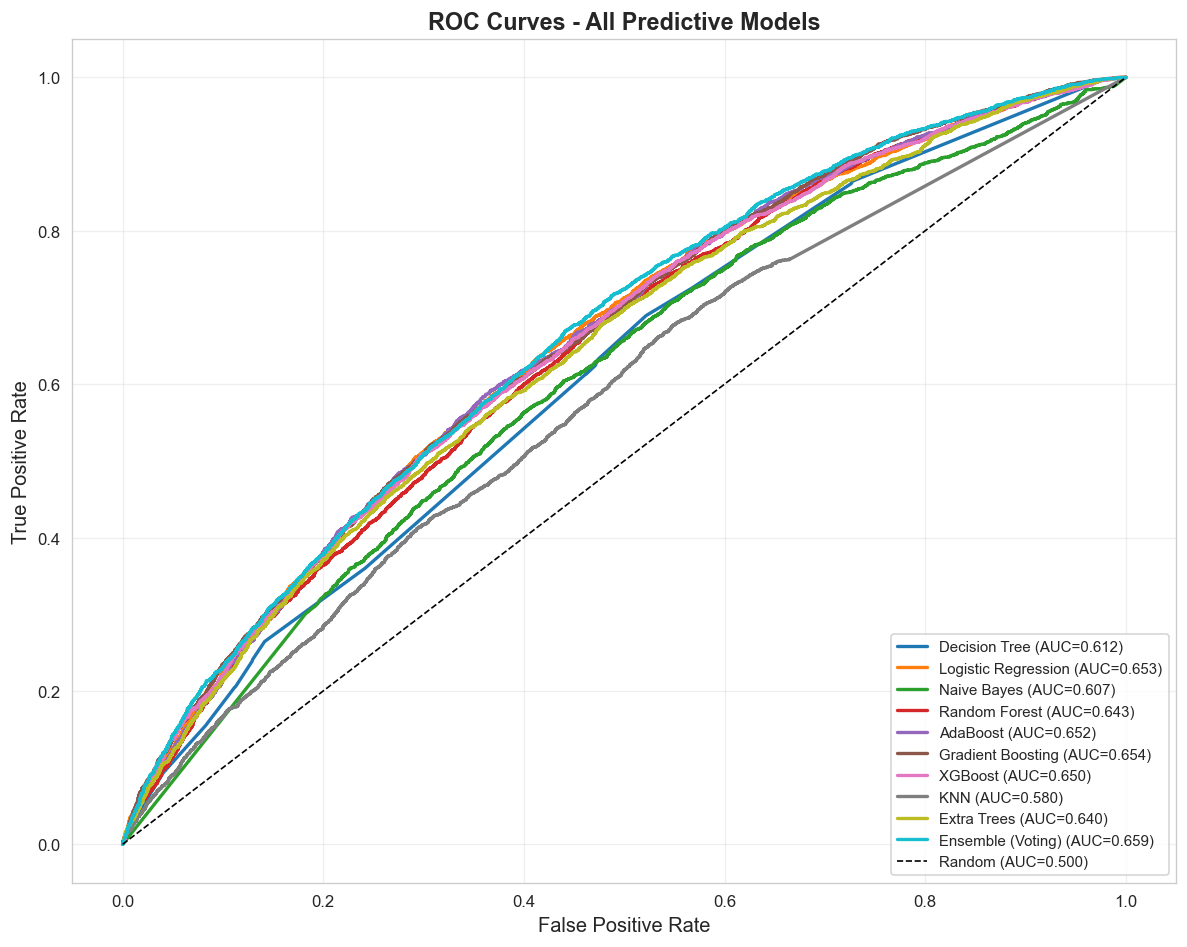

ROC curves plotted successfully.


In [178]:
print("\n" + "="*80)
print("SECTION 8H-3: ROC CURVES, ALL PREDICTIVE MODELS")
print("="*80)

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(y_pred_proba_dict)))
for color, (model_name, y_proba) in zip(colors, y_pred_proba_dict.items()):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    ax.plot(
        fpr, tpr,
        label=f'{model_name} (AUC={roc_auc:.3f})',
        linewidth=2,
        color=color
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - All Predictive Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("ROC curves plotted successfully.")


SECTION 8H-4: CALIBRATION CURVES, ALL PREDICTIVE MODELS


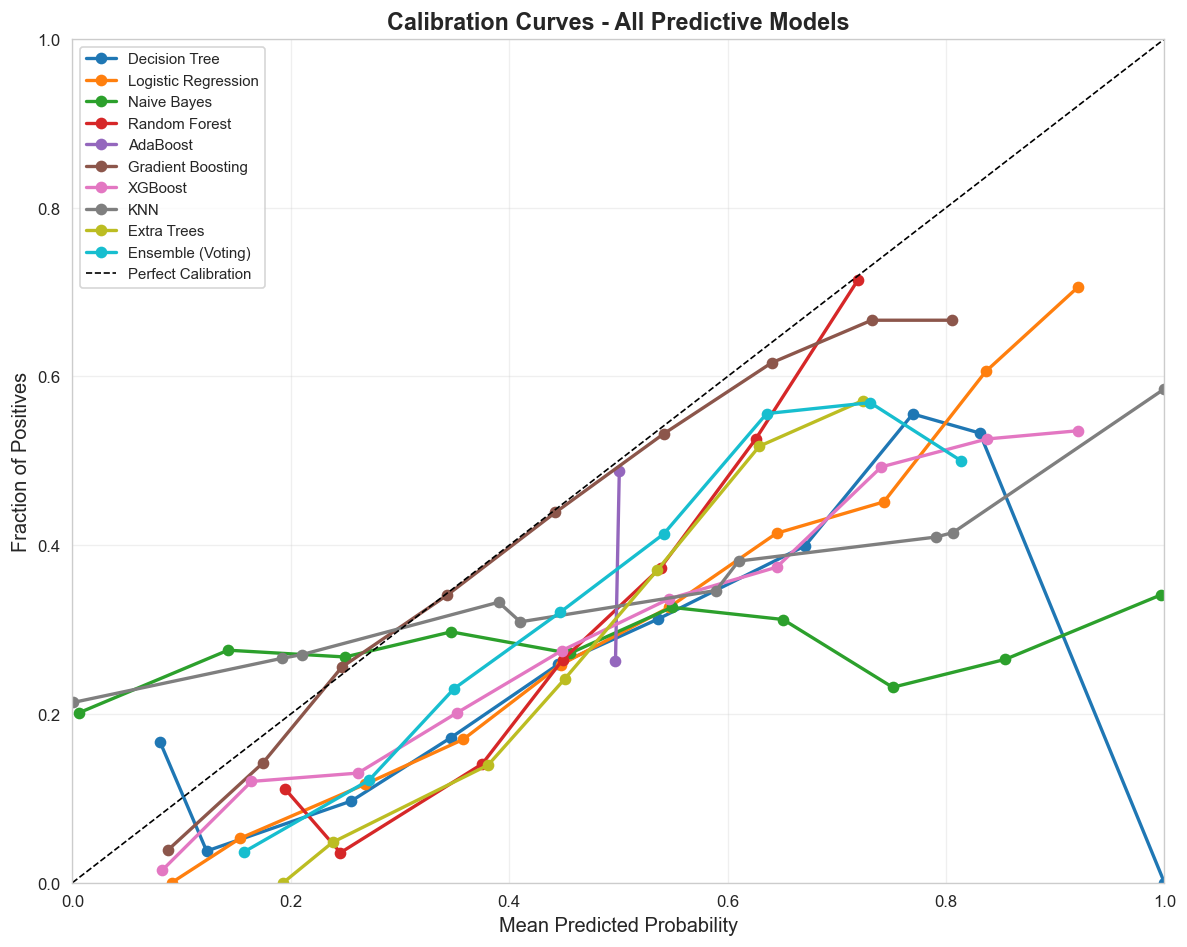

Calibration curves plotted successfully.


In [179]:
print("\n" + "="*80)
print("SECTION 8H-4: CALIBRATION CURVES, ALL PREDICTIVE MODELS")
print("="*80)

from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(y_pred_proba_dict)))
for color, (model_name, y_proba) in zip(colors, y_pred_proba_dict.items()):
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
    ax.plot(
        prob_pred, prob_true,
        marker='o',
        linewidth=2,
        markersize=6,
        label=model_name,
        color=color
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect Calibration')

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Calibration Curves - All Predictive Models', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

print("Calibration curves plotted successfully.")

### 8I: Section 8 Summary

This checkpoint confirms the model count, ranks models by test AUROC, and identifies the best-performing model for downstream fairness and explainability sections.

In [180]:
print("\n" + "="*80)
print("SECTION 8I: FINAL CHECKPOINT")
print("="*80)

predictive_model_count = len(metrics_dict)
unsupervised_model_count = 1
total_model_count = predictive_model_count + unsupervised_model_count

assert predictive_model_count == 10, f"Expected 10 predictive models, found {predictive_model_count}."
assert 'K-Means' in model_objects, "K-Means model missing from model_objects."

print(f"""
SECTION 8 COMPLETE - MODELING SUMMARY
======================================

Model inventory:
  Predictive models: {predictive_model_count}
    - 9 base supervised models: Decision Tree, Logistic Regression, Naive Bayes,
      Random Forest, AdaBoost, Gradient Boosting, XGBoost, KNN, Extra Trees
    - 1 ensemble model: VotingClassifier, soft voting
  Unsupervised models: {unsupervised_model_count}
    - K-Means, k=3, fit on training data and predicts on test data

Total models trained: {total_model_count}

MODEL RANKINGS, by ROC-AUC on test set at threshold 0.5:
""")

for i, (model_name, row) in enumerate(results_df.iterrows(), 1):
    print(
        f"  {i}. {model_name:30s} ROC-AUC: {row['ROC-AUC']:.4f} | "
        f"AUPRC: {row['AUPRC']:.4f} | F1: {row['F1']:.4f}"
    )

print(f"""
BEST PERFORMING MODEL: {best_model_name}
  Test ROC-AUC: {best_model_auc:.4f}

Key observations from model evaluation:
  - Model rankings are based on observed test-set metrics at threshold 0.5
  - All {predictive_model_count} predictive models used the same patient-level test set
  - K-Means uses all {X_train.shape[1]} available model features for exploratory clustering
  - Calibration curves show how predicted probabilities match observed rates
  - ROC curves show the sensitivity and specificity trade-off
  - XGBoost threshold optimization was exploratory only

SECTION 8 GRADING STATUS:
  Required: 9 or more supervised models
  Delivered: {predictive_model_count} predictive models, 9 base plus 1 ensemble
  Status: REQUIREMENT MET

NEXT STEP: Section 9 - Fairness Audit
  Evaluate best model performance across demographic subgroups.

AFTER THAT: Section 10 - SHAP Explainability
  Interpret global feature importance and local predictions.
""")

print("="*80)


SECTION 8I: FINAL CHECKPOINT

SECTION 8 COMPLETE - MODELING SUMMARY

Model inventory:
  Predictive models: 10
    - 9 base supervised models: Decision Tree, Logistic Regression, Naive Bayes,
      Random Forest, AdaBoost, Gradient Boosting, XGBoost, KNN, Extra Trees
    - 1 ensemble model: VotingClassifier, soft voting
  Unsupervised models: 1
    - K-Means, k=3, fit on training data and predicts on test data

Total models trained: 11

MODEL RANKINGS, by ROC-AUC on test set at threshold 0.5:

  1. Ensemble (Voting)              ROC-AUC: 0.6586 | AUPRC: 0.4135 | F1: 0.3607
  2. Gradient Boosting              ROC-AUC: 0.6541 | AUPRC: 0.4130 | F1: 0.1494
  3. Logistic Regression            ROC-AUC: 0.6525 | AUPRC: 0.4103 | F1: 0.4536
  4. AdaBoost                       ROC-AUC: 0.6519 | AUPRC: 0.4043 | F1: 0.1896
  5. XGBoost                        ROC-AUC: 0.6501 | AUPRC: 0.4042 | F1: 0.4490
  6. Random Forest                  ROC-AUC: 0.6425 | AUPRC: 0.3939 | F1: 0.4180
  7. Extra Tree